In [1]:
# ── CELL 0: INSTALL & IMPORTS ──────────────────────────
import subprocess, sys
for pkg in ['prophet', 'lightgbm']:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from prophet import Prophet
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_absolute_percentage_error
from scipy.stats import mstats
from scipy.stats.mstats import winsorize
import statsmodels.api as sm
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from numpy.polynomial import polynomial as P

print("✅ Semua library berhasil diimport")

✅ Semua library berhasil diimport


In [2]:
# ── CELL 1: LOAD DATA & BASIC CHECKS ──────────────────
df_polis = pd.read_csv('Data_Polis.csv')
df_klaim = pd.read_csv('Data_Klaim.csv')

# Strip whitespace semua kolom string
df_polis.columns = df_polis.columns.str.strip()
df_klaim.columns = df_klaim.columns.str.strip()

for col in df_polis.select_dtypes('object').columns:
    df_polis[col] = df_polis[col].str.strip()
for col in df_klaim.select_dtypes('object').columns:
    df_klaim[col] = df_klaim[col].str.strip()

# Parse tanggal polis
df_polis['Tanggal Lahir']          = pd.to_datetime(df_polis['Tanggal Lahir'], format='%Y%m%d')
df_polis['Tanggal Efektif Polis']  = pd.to_datetime(df_polis['Tanggal Efektif Polis'], format='%Y%m%d')

# Parse tanggal klaim
df_klaim['Tanggal Pembayaran Klaim']  = pd.to_datetime(df_klaim['Tanggal Pembayaran Klaim'], errors='coerce')
df_klaim['Tanggal Pasien Masuk RS']   = pd.to_datetime(df_klaim['Tanggal Pasien Masuk RS'],  errors='coerce')
df_klaim['Tanggal Pasien Keluar RS']  = pd.to_datetime(df_klaim['Tanggal Pasien Keluar RS'], errors='coerce')

# ── MISSING VALUES ─────────────────────────────────────
print("=" * 50)
print("MISSING VALUES — DATA POLIS")
print("=" * 50)
mv_polis = df_polis.isnull().sum()
print(mv_polis[mv_polis > 0] if mv_polis.sum() > 0 else "✅ Tidak ada missing value")

print("\n" + "=" * 50)
print("MISSING VALUES — DATA KLAIM")
print("=" * 50)
mv_klaim = df_klaim.isnull().sum()
print(mv_klaim[mv_klaim > 0] if mv_klaim.sum() > 0 else "✅ Tidak ada missing value")

# ── FILTER PAID & DEDUPLIKASI ──────────────────────────
df_klaim = df_klaim[df_klaim['Status Klaim'] == 'PAID'].copy()
before   = len(df_klaim)
df_klaim = df_klaim.drop_duplicates(subset='Claim ID')
print(f"\n✅ Filter PAID: {len(df_klaim)} rows")
print(f"✅ Duplikat dihapus: {before - len(df_klaim)} rows")

# ── WINSORIZE 1%-99% DI LEVEL INDIVIDUAL KLAIM ────────
# Dilakukan sebelum agregasi — lebih tepat untuk data klaim yang skewed
low_p  = np.percentile(df_klaim['Nominal Klaim Yang Disetujui'], 1)
high_p = np.percentile(df_klaim['Nominal Klaim Yang Disetujui'], 99)
df_klaim['Nominal Klaim Yang Disetujui'] = df_klaim['Nominal Klaim Yang Disetujui'].clip(low_p, high_p)

print(f"\n✅ Winsorize 1%-99% selesai")
print(f"   Lower bound : Rp {low_p:,.0f}")
print(f"   Upper bound : Rp {high_p:,.0f}")

# ── PERIODE KLAIM ──────────────────────────────────────
df_klaim['Periode_Klaim'] = (
    df_klaim['Tanggal Pasien Masuk RS']
    .dt.to_period('M')
    .dt.to_timestamp()
)

print(f"\n✅ Cell 1 selesai")
print(f"   Polis : {df_polis.shape}")
print(f"   Klaim : {df_klaim.shape}")

MISSING VALUES — DATA POLIS
✅ Tidak ada missing value

MISSING VALUES — DATA KLAIM
Inpatient/Outpatient        37
ICD Diagnosis                6
ICD Description              6
Tanggal Pembayaran Klaim    37
Lokasi RS                    7
dtype: int64

✅ Filter PAID: 4627 rows
✅ Duplikat dihapus: 0 rows

✅ Winsorize 1%-99% selesai
   Lower bound : Rp 187,242
   Upper bound : Rp 633,686,130

✅ Cell 1 selesai
   Polis : (4096, 6)
   Klaim : (4627, 14)


In [3]:
# ── CELL 3: AGREGASI BULANAN, EXPOSURE & FEATURE ENGINEERING ──

# ── AGREGASI BULANAN ───────────────────────────────────
df_monthly = df_klaim.groupby('Periode_Klaim').agg(
    Claim_Frequency=('Claim ID', 'count'),
    Total_Claim=('Nominal Klaim Yang Disetujui', 'sum'),
    Claim_Severity=('Nominal Klaim Yang Disetujui', 'mean')
).reset_index()

df_monthly = df_monthly.sort_values('Periode_Klaim').reset_index(drop=True)

print("=" * 50)
print("DATA BULANAN")
print("=" * 50)
display(df_monthly)
print(f"\nRentang  : {df_monthly['Periode_Klaim'].min()} → {df_monthly['Periode_Klaim'].max()}")
print(f"Total    : {len(df_monthly)} bulan")

# ── EXPOSURE PER BULAN ─────────────────────────────────
exposure_list = []
for period in df_monthly['Periode_Klaim']:
    period_end = period + pd.offsets.MonthEnd(0)
    n_active   = df_polis[
        df_polis['Tanggal Efektif Polis'] <= period_end
    ].shape[0]
    exposure_list.append({'Periode_Klaim': period, 'Exposure': n_active})

df_exposure = pd.DataFrame(exposure_list)
df_monthly  = df_monthly.merge(df_exposure, on='Periode_Klaim', how='left')

df_monthly['Claim_Rate'] = (
    df_monthly['Claim_Frequency'] / df_monthly['Exposure']
)

print("\n" + "=" * 50)
print("EXPOSURE PER BULAN")
print("=" * 50)
display(df_monthly[['Periode_Klaim', 'Exposure', 'Claim_Rate']])

# ── EXPOSURE FORECAST: TREN LINEAR ────────────────────
time_idx      = np.arange(len(df_monthly))
exp_values    = df_monthly['Exposure'].values
coeffs        = np.polyfit(time_idx, exp_values, 1)
exposure_poly = np.poly1d(coeffs)

future_idx_start = len(df_monthly)
future_exposure  = [
    max(int(exposure_poly(future_idx_start + i)), df_monthly['Exposure'].max())
    for i in range(17)
]

print(f"\n✅ Tren linear exposure: slope = {coeffs[0]:.2f} polis/bulan")
print(f"   Exposure historis terakhir : {df_monthly['Exposure'].iloc[-1]}")
print(f"   Exposure forecast bulan 1  : {future_exposure[0]}")
print(f"   Exposure forecast bulan 17 : {future_exposure[16]}")

# ── CALENDAR FEATURES ──────────────────────────────────
df_monthly['Time_Index'] = np.arange(len(df_monthly))
df_monthly['Month']      = df_monthly['Periode_Klaim'].dt.month
df_monthly['Quarter']    = df_monthly['Periode_Klaim'].dt.quarter

df_monthly['Month_Sin']   = np.sin(2 * np.pi * df_monthly['Month'] / 12)
df_monthly['Month_Cos']   = np.cos(2 * np.pi * df_monthly['Month'] / 12)
df_monthly['Quarter_Sin'] = np.sin(2 * np.pi * df_monthly['Quarter'] / 4)
df_monthly['Quarter_Cos'] = np.cos(2 * np.pi * df_monthly['Quarter'] / 4)

# ── LAG FEATURES ──────────────────────────────────────
df_monthly['Freq_Lag_1']  = df_monthly['Claim_Frequency'].shift(1)
df_monthly['Freq_Lag_2']  = df_monthly['Claim_Frequency'].shift(2)
df_monthly['Freq_Lag_3']  = df_monthly['Claim_Frequency'].shift(3)

df_monthly['Sev_Lag_1']   = df_monthly['Claim_Severity'].shift(1)
df_monthly['Sev_Lag_2']   = df_monthly['Claim_Severity'].shift(2)
df_monthly['Sev_Lag_3']   = df_monthly['Claim_Severity'].shift(3)

df_monthly['Total_Lag_1'] = df_monthly['Total_Claim'].shift(1)
df_monthly['Total_Lag_2'] = df_monthly['Total_Claim'].shift(2)

# ── ROLLING FEATURES ──────────────────────────────────
df_monthly['Freq_Rolling_3']  = df_monthly['Claim_Frequency'].shift(1).rolling(3).mean()
df_monthly['Sev_Rolling_3']   = df_monthly['Claim_Severity'].shift(1).rolling(3).mean()
df_monthly['Total_Rolling_3'] = df_monthly['Total_Claim'].shift(1).rolling(3).mean()

df_monthly['Freq_Rolling_6']  = df_monthly['Claim_Frequency'].shift(1).rolling(6).mean()
df_monthly['Sev_Rolling_6']   = df_monthly['Claim_Severity'].shift(1).rolling(6).mean()
df_monthly['Total_Rolling_6'] = df_monthly['Total_Claim'].shift(1).rolling(6).mean()

df_monthly['Freq_Std_3'] = df_monthly['Claim_Frequency'].shift(1).rolling(3).std()
df_monthly['Sev_Std_3']  = df_monthly['Claim_Severity'].shift(1).rolling(3).std()

df_monthly['Freq_Growth'] = (
    df_monthly['Claim_Frequency'] / df_monthly['Freq_Lag_1'] - 1
).replace([np.inf, -np.inf], 0)

df_monthly['Sev_Growth'] = (
    df_monthly['Claim_Severity'] / df_monthly['Sev_Lag_1'] - 1
).replace([np.inf, -np.inf], 0)

# ── NORMALISASI FITUR NUMERIK ──────────────────────────
from sklearn.preprocessing import StandardScaler

FEATURES_TO_SCALE = [
    'Freq_Rolling_3', 'Freq_Rolling_6', 'Freq_Std_3',
    'Sev_Rolling_3',  'Sev_Rolling_6',  'Sev_Std_3',
    'Total_Rolling_3','Total_Rolling_6',
    'Freq_Lag_1', 'Freq_Lag_2', 'Freq_Lag_3',
    'Sev_Lag_1',  'Sev_Lag_2',  'Sev_Lag_3',
    'Total_Lag_1','Total_Lag_2',
]

scaler     = StandardScaler()
scale_cols = [f for f in FEATURES_TO_SCALE if f in df_monthly.columns]

# Simpan unscaled untuk seasonal naive & interpretasi
df_monthly_unscaled = df_monthly.copy()

mask = df_monthly[scale_cols].notna().all(axis=1)
df_monthly.loc[mask, scale_cols] = scaler.fit_transform(
    df_monthly.loc[mask, scale_cols]
)

print("\n" + "=" * 50)
print("NORMALISASI FITUR — StandardScaler")
print("=" * 50)
print(f"  Fitur yang dinormalisasi     : {len(scale_cols)}")
print(f"  Fitur yang TIDAK dinormalisasi:")
print(f"    - Target variable (Frequency, Severity, Total)")
print(f"    - Cyclical features (Month_Sin/Cos, Quarter_Sin/Cos)")
print(f"    - Time_Index")
print(f"    - Exposure")
print(f"\n  Statistik setelah scaling (5 fitur pertama):")
print(f"  {'Fitur':<20} {'Mean':>8} {'Std':>8}")
print(f"  {'-'*40}")
for col in scale_cols[:5]:
    print(f"  {col:<20} {df_monthly[col].mean():>8.4f} "
          f"{df_monthly[col].std():>8.4f}")
print(f"\n✅ Normalisasi selesai")

# ── SEASONAL NAIVE PRECOMPUTE ──────────────────────────
# Gunakan df_monthly_unscaled agar nilai naive tetap dalam skala asli
seasonal_naive = {}
for month in range(1, 13):
    month_data  = df_monthly_unscaled[df_monthly_unscaled['Month'] == month]
    surrounding = df_monthly_unscaled[
        df_monthly_unscaled['Month'].isin(
            [(month - 1) % 12 + 1, month, (month + 1) % 12 + 1]
        )
    ]
    for target in ['Claim_Frequency', 'Claim_Severity', 'Total_Claim']:
        if len(month_data) >= 2:
            val = month_data[target].mean()
        else:
            actual_val      = month_data[target].mean() if len(month_data) > 0 \
                              else surrounding[target].mean()
            surrounding_val = surrounding[target].mean()
            val             = 0.5 * actual_val + 0.5 * surrounding_val
        seasonal_naive[(month, target)] = val

print("\n✅ Seasonal Naive per bulan:")
for month in range(1, 13):
    print(f"   Bulan {month:02d} | "
          f"Freq: {seasonal_naive[(month, 'Claim_Frequency')]:.1f} | "
          f"Sev: {seasonal_naive[(month, 'Claim_Severity')]/1e6:.2f}M | "
          f"Total: {seasonal_naive[(month, 'Total_Claim')]/1e9:.3f}B")

# ── FEATURE SETS PER TARGET ───────────────────────────
FEATURES_FREQ = [
    'Time_Index', 'Month_Sin', 'Month_Cos', 'Quarter_Sin', 'Quarter_Cos',
    'Freq_Lag_1', 'Freq_Lag_2', 'Freq_Lag_3',
    'Freq_Rolling_3', 'Freq_Rolling_6', 'Freq_Std_3',
    'Total_Lag_1', 'Exposure',
]

FEATURES_SEV = [
    'Time_Index', 'Month_Sin', 'Month_Cos', 'Quarter_Sin', 'Quarter_Cos',
    'Sev_Lag_1', 'Sev_Lag_2', 'Sev_Lag_3',
    'Sev_Rolling_3', 'Sev_Rolling_6', 'Sev_Std_3',
    'Freq_Lag_1', 'Exposure',
]

FEATURES_TOTAL = [
    'Time_Index', 'Month_Sin', 'Month_Cos', 'Quarter_Sin', 'Quarter_Cos',
    'Total_Lag_1', 'Total_Lag_2',
    'Total_Rolling_3', 'Total_Rolling_6',
    'Freq_Lag_1', 'Sev_Lag_1', 'Exposure',
]

print(f"\n✅ Feature sets:")
print(f"   Frequency : {len(FEATURES_FREQ)} fitur")
print(f"   Severity  : {len(FEATURES_SEV)} fitur")
print(f"   Total     : {len(FEATURES_TOTAL)} fitur")

print("\n✅ Cell 3 selesai")

DATA BULANAN


,Periode_Klaim,Claim_Frequency,Total_Claim,Claim_Severity
0,2024-01-01,302,1.895190e+10,6.275465e+07
1,2024-02-01,208,1.264589e+10,6.079755e+07
2,2024-03-01,278,1.414070e+10,5.086583e+07
3,2024-04-01,239,1.120960e+10,4.690211e+07
4,2024-05-01,263,1.123643e+10,4.272406e+07
5,2024-06-01,225,1.212653e+10,5.389569e+07
6,2024-07-01,257,1.374646e+10,5.348818e+07
7,2024-08-01,228,1.196234e+10,5.246642e+07
8,2024-09-01,208,1.108477e+10,5.329216e+07
9,2024-10-01,274,1.268139e+10,4.628243e+07



Rentang  : 2024-01-01 00:00:00 → 2025-07-01 00:00:00
Total    : 19 bulan

EXPOSURE PER BULAN


,Periode_Klaim,Exposure,Claim_Rate
0,2024-01-01,4096,0.073730
1,2024-02-01,4096,0.050781
2,2024-03-01,4096,0.067871
3,2024-04-01,4096,0.058350
4,2024-05-01,4096,0.064209
5,2024-06-01,4096,0.054932
6,2024-07-01,4096,0.062744
7,2024-08-01,4096,0.055664
8,2024-09-01,4096,0.050781
9,2024-10-01,4096,0.066895



✅ Tren linear exposure: slope = 0.00 polis/bulan
   Exposure historis terakhir : 4096
   Exposure forecast bulan 1  : 4096
   Exposure forecast bulan 17 : 4096

NORMALISASI FITUR — StandardScaler
  Fitur yang dinormalisasi     : 16
  Fitur yang TIDAK dinormalisasi:
    - Target variable (Frequency, Severity, Total)
    - Cyclical features (Month_Sin/Cos, Quarter_Sin/Cos)
    - Time_Index
    - Exposure

  Statistik setelah scaling (5 fitur pertama):
  Fitur                    Mean      Std
  ----------------------------------------
  Freq_Rolling_3        47.7708 102.7932
  Freq_Rolling_6        -0.0000   1.0408
  Freq_Std_3             6.4743  14.9332
  Sev_Rolling_3        9864073.4085 21307532.1881
  Sev_Rolling_6          0.0000   1.0408

✅ Normalisasi selesai

✅ Seasonal Naive per bulan:
   Bulan 01 | Freq: 259.0 | Sev: 53.35M | Total: 14.222B
   Bulan 02 | Freq: 227.0 | Sev: 59.56M | Total: 13.496B
   Bulan 03 | Freq: 254.0 | Sev: 51.96M | Total: 13.171B
   Bulan 04 | Freq: 223.

In [4]:
# ── CELL 4: WALK-FORWARD VALIDATION ───────────────────

# ── HELPER FUNCTIONS ───────────────────────────────────
def safe_mape(y_true, y_pred):
    y_true = np.array(y_true, dtype=float)
    y_pred = np.array(y_pred, dtype=float)
    mask   = y_true != 0
    if mask.sum() == 0:
        return np.nan
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

def run_prophet(train_df, target_col, periods=1):
    """
    Prophet dengan quarterly seasonality.
    Yearly seasonality dimatikan — tidak reliable dengan < 24 bulan data.
    """
    prophet_df = train_df[['Periode_Klaim', target_col]].rename(
        columns={'Periode_Klaim': 'ds', target_col: 'y'}
    )
    model = Prophet(
        yearly_seasonality=False,
        weekly_seasonality=False,
        daily_seasonality=False,
        seasonality_mode='additive',
        changepoint_prior_scale=0.01,   # conservative — hindari overfitting trend
        seasonality_prior_scale=1.0,
    )
    # Quarterly seasonality lebih reliable untuk 19 bulan data
    model.add_seasonality(name='quarterly', period=91.25, fourier_order=3)
    model.fit(prophet_df, algorithm='Newton')

    future   = model.make_future_dataframe(periods=periods, freq='MS')
    forecast = model.predict(future)
    pred     = forecast['yhat'].iloc[-periods:].values
    return np.clip(pred, 0, None)

def run_lgbm(train_df, val_df, features, target_col):
    """LightGBM dengan regularisasi untuk data kecil."""
    # Drop NaN di features
    train_clean = train_df.dropna(subset=features)
    val_clean   = val_df.dropna(subset=features)

    if len(train_clean) < 5 or len(val_clean) == 0:
        return np.array([np.nan])

    X_train = train_clean[features]
    y_train = train_clean[target_col]
    X_val   = val_clean[features]

    model = LGBMRegressor(
        n_estimators=200,
        max_depth=2,
        num_leaves=4,
        min_child_samples=3,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.5,
        reg_lambda=1.0,
        random_state=42,
        verbose=-1
    )
    model.fit(X_train, y_train)
    pred = model.predict(X_val)
    return np.clip(pred, 0, None)

def get_seasonal_naive(month, target_col):
    """Ambil seasonal naive value untuk bulan dan target tertentu."""
    return seasonal_naive.get((month, target_col), 0)

# ── WALK-FORWARD SPLITS ────────────────────────────────
# Min train 14 bulan → fold pertama val di bulan ke-15
MIN_TRAIN = 14

splits = []
n      = len(df_monthly)
for val_idx in range(MIN_TRAIN, n):
    train = df_monthly.iloc[:val_idx].copy()
    val   = df_monthly.iloc[val_idx:val_idx + 1].copy()
    splits.append((train, val))

print("=" * 50)
print("WALK-FORWARD SPLITS")
print("=" * 50)
print(f"Jumlah fold: {len(splits)}")
for i, (tr, vl) in enumerate(splits):
    print(f"  Fold {i+1} | Train: "
          f"{tr['Periode_Klaim'].min().strftime('%Y-%m')} → "
          f"{tr['Periode_Klaim'].max().strftime('%Y-%m')} "
          f"({len(tr)} bln) | Val: "
          f"{vl['Periode_Klaim'].iloc[0].strftime('%Y-%m')}")

# ── VALIDASI PER MODEL PER TARGET ─────────────────────
targets = {
    'Claim_Frequency' : FEATURES_FREQ,
    'Claim_Severity'  : FEATURES_SEV,
    'Total_Claim'     : FEATURES_TOTAL,
}

val_results = {
    target: {
        'prophet_preds' : [],
        'lgbm_preds'    : [],
        'naive_preds'   : [],
        'actuals'       : [],
    }
    for target in targets
}

print("\n" + "=" * 50)
print("RUNNING WALK-FORWARD VALIDATION")
print("=" * 50)

for i, (train, val) in enumerate(splits):
    val_month  = val['Periode_Klaim'].iloc[0].month
    val_period = val['Periode_Klaim'].iloc[0].strftime('%Y-%m')

    for target_col, features in targets.items():
        actual = val[target_col].iloc[0]
        val_results[target_col]['actuals'].append(actual)

        # Prophet
        try:
            p_prophet = run_prophet(train, target_col, periods=1)[0]
        except Exception:
            p_prophet = train[target_col].mean()
        val_results[target_col]['prophet_preds'].append(p_prophet)

        # LightGBM
        p_lgbm = run_lgbm(train, val, features, target_col)
        p_lgbm = p_lgbm[0] if len(p_lgbm) > 0 and not np.isnan(p_lgbm[0]) \
                 else train[target_col].mean()
        val_results[target_col]['lgbm_preds'].append(p_lgbm)

        # Seasonal Naive
        p_naive = get_seasonal_naive(val_month, target_col)
        val_results[target_col]['naive_preds'].append(p_naive)

    print(f"  Fold {i+1} selesai | Val: {val_period}")

# ── HITUNG MAPE PER MODEL ──────────────────────────────
print("\n" + "=" * 60)
print("VALIDATION MAPE PER MODEL")
print("=" * 60)
print(f"{'Target':<20} {'Prophet':>10} {'LightGBM':>10} {'Naive':>10}")
print("-" * 60)

mape_scores = {}
for target_col in targets:
    actuals = val_results[target_col]['actuals']
    m_p     = safe_mape(actuals, val_results[target_col]['prophet_preds'])
    m_l     = safe_mape(actuals, val_results[target_col]['lgbm_preds'])
    m_n     = safe_mape(actuals, val_results[target_col]['naive_preds'])
    mape_scores[target_col] = {'prophet': m_p, 'lgbm': m_l, 'naive': m_n}
    print(f"  {target_col:<18} {m_p:>9.2f}% {m_l:>9.2f}% {m_n:>9.2f}%")

# ── HITUNG BOBOT INVERSE MAPE ─────────────────────────
# Bobot = 1/MAPE dinormalisasi, dihitung independen per model
# Bukan dioptimasi di validation set → lebih robust
print("\n" + "=" * 60)
print("BOBOT ENSEMBLE — INVERSE MAPE (INDEPENDEN)")
print("=" * 60)
print(f"{'Target':<20} {'w_Prophet':>10} {'w_LightGBM':>10} {'w_Naive':>10}")
print("-" * 60)

base_weights = {}
for target_col in targets:
    scores = mape_scores[target_col]
    # Hindari division by zero
    eps   = 1e-6
    inv_p = 1 / (scores['prophet'] + eps)
    inv_l = 1 / (scores['lgbm']    + eps)
    inv_n = 1 / (scores['naive']   + eps)
    total = inv_p + inv_l + inv_n

    w_p = round(inv_p / total, 3)
    w_l = round(inv_l / total, 3)
    w_n = round(inv_n / total, 3)
    # Normalisasi agar tepat = 1
    w_n = round(1 - w_p - w_l, 3)

    base_weights[target_col] = {'prophet': w_p, 'lgbm': w_l, 'naive': w_n}
    print(f"  {target_col:<18} {w_p:>10.3f} {w_l:>10.3f} {w_n:>10.3f}")

# ── ENSEMBLE MAPE DI VALIDASI ──────────────────────────
print("\n" + "=" * 60)
print("ENSEMBLE MAPE DI VALIDASI (BASE WEIGHTS)")
print("=" * 60)

ensemble_val_mapes = {}
for target_col in targets:
    actuals = np.array(val_results[target_col]['actuals'])
    p_preds = np.array(val_results[target_col]['prophet_preds'])
    l_preds = np.array(val_results[target_col]['lgbm_preds'])
    n_preds = np.array(val_results[target_col]['naive_preds'])

    w = base_weights[target_col]
    ensemble_preds = (
        w['prophet'] * p_preds +
        w['lgbm']    * l_preds +
        w['naive']   * n_preds
    )
    m_ens = safe_mape(actuals, ensemble_preds)
    ensemble_val_mapes[target_col] = m_ens
    print(f"  {target_col:<20}: {m_ens:.2f}%")

avg_ens_mape = np.mean(list(ensemble_val_mapes.values()))
print(f"\n  Average Ensemble MAPE : {avg_ens_mape:.2f}%")

print("\n✅ Cell 4 selesai")

WALK-FORWARD SPLITS
Jumlah fold: 5
  Fold 1 | Train: 2024-01 → 2025-02 (14 bln) | Val: 2025-03
  Fold 2 | Train: 2024-01 → 2025-03 (15 bln) | Val: 2025-04
  Fold 3 | Train: 2024-01 → 2025-04 (16 bln) | Val: 2025-05
  Fold 4 | Train: 2024-01 → 2025-05 (17 bln) | Val: 2025-06
  Fold 5 | Train: 2024-01 → 2025-06 (18 bln) | Val: 2025-07

RUNNING WALK-FORWARD VALIDATION


16:21:37 - cmdstanpy - INFO - Chain [1] start processing
16:21:38 - cmdstanpy - INFO - Chain [1] done processing
16:21:46 - cmdstanpy - INFO - Chain [1] start processing
16:21:46 - cmdstanpy - INFO - Chain [1] done processing
16:21:48 - cmdstanpy - INFO - Chain [1] start processing
16:21:48 - cmdstanpy - INFO - Chain [1] done processing


  Fold 1 selesai | Val: 2025-03


16:21:50 - cmdstanpy - INFO - Chain [1] start processing
16:21:50 - cmdstanpy - INFO - Chain [1] done processing
16:21:51 - cmdstanpy - INFO - Chain [1] start processing
16:21:52 - cmdstanpy - INFO - Chain [1] done processing
16:21:52 - cmdstanpy - INFO - Chain [1] start processing
16:21:52 - cmdstanpy - INFO - Chain [1] done processing


  Fold 2 selesai | Val: 2025-04


...

  Fold 3 selesai | Val: 2025-05


16:21:56 - cmdstanpy - INFO - Chain [1] start processing
16:21:56 - cmdstanpy - INFO - Chain [1] done processing
16:21:57 - cmdstanpy - INFO - Chain [1] start processing
16:21:57 - cmdstanpy - INFO - Chain [1] done processing
16:21:58 - cmdstanpy - INFO - Chain [1] start processing
16:21:58 - cmdstanpy - INFO - Chain [1] done processing


  Fold 4 selesai | Val: 2025-06


16:21:58 - cmdstanpy - INFO - Chain [1] start processing
16:21:59 - cmdstanpy - INFO - Chain [1] done processing
16:21:59 - cmdstanpy - INFO - Chain [1] start processing
16:22:00 - cmdstanpy - INFO - Chain [1] done processing
16:22:00 - cmdstanpy - INFO - Chain [1] start processing
16:22:00 - cmdstanpy - INFO - Chain [1] done processing


  Fold 5 selesai | Val: 2025-07

VALIDATION MAPE PER MODEL
Target                  Prophet   LightGBM      Naive
------------------------------------------------------------
  Claim_Frequency        14.36%      6.48%      5.23%
  Claim_Severity         16.15%      3.09%      4.34%
  Total_Claim            16.00%      5.95%      3.82%

BOBOT ENSEMBLE — INVERSE MAPE (INDEPENDEN)
Target                w_Prophet w_LightGBM    w_Naive
------------------------------------------------------------
  Claim_Frequency         0.168      0.372      0.460
  Claim_Severity          0.101      0.525      0.374
  Total_Claim             0.127      0.341      0.532

ENSEMBLE MAPE DI VALIDASI (BASE WEIGHTS)
  Claim_Frequency     : 6.12%
  Claim_Severity      : 3.62%
  Total_Claim         : 3.89%

  Average Ensemble MAPE : 4.54%

✅ Cell 4 selesai


TRAINING PROPHET — Full Data


16:22:01 - cmdstanpy - INFO - Chain [1] start processing
16:22:01 - cmdstanpy - INFO - Chain [1] done processing


  ✅ Prophet Frequency selesai


16:22:01 - cmdstanpy - INFO - Chain [1] start processing
16:22:01 - cmdstanpy - INFO - Chain [1] done processing


  ✅ Prophet Severity selesai


16:22:02 - cmdstanpy - INFO - Chain [1] start processing
16:22:02 - cmdstanpy - INFO - Chain [1] done processing


  ✅ Prophet Total selesai

TRAINING LIGHTGBM — Full Data
  ✅ LightGBM Frequency selesai
  ✅ LightGBM Severity selesai
  ✅ LightGBM Total selesai

IN-SAMPLE MAPE LIGHTGBM (referensi, bukan evaluasi utama)
  Frequency  : 0.45%
  Severity   : 1.02%
  Total Claim: 0.40%
  ⚠️  In-sample MAPE selalu lebih rendah dari walk-forward — 
     gunakan Cell 4 sebagai acuan evaluasi utama

FEATURE IMPORTANCE — LightGBM


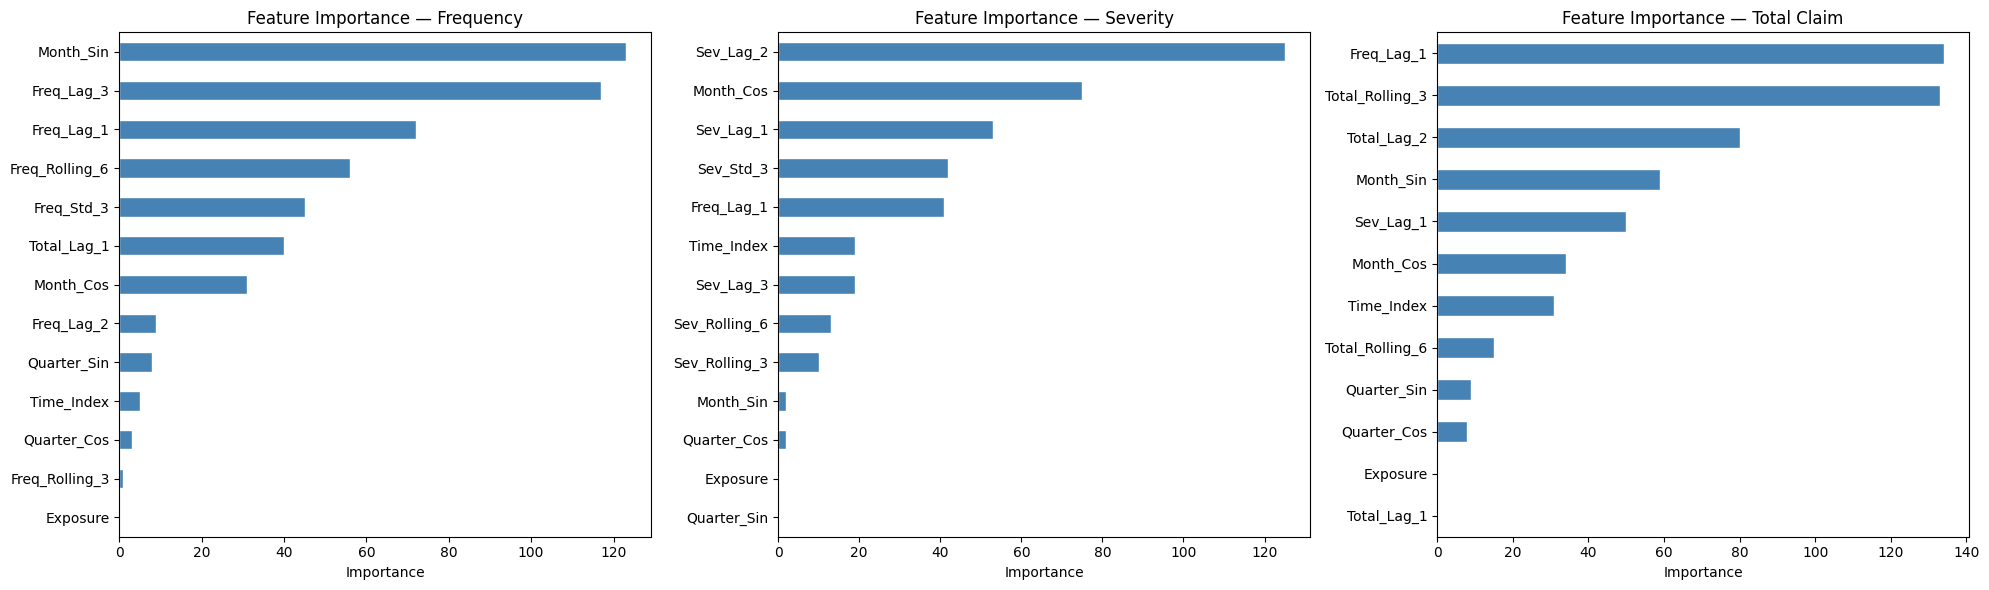


RINGKASAN BOBOT ENSEMBLE (dari Cell 4)
Target                  Prophet   LightGBM      Naive
------------------------------------------------------------
  Claim_Frequency         0.168      0.372      0.460
  Claim_Severity          0.101      0.525      0.374
  Total_Claim             0.127      0.341      0.532

✅ Cell 5 selesai — semua model siap untuk forecasting


In [5]:
# ── CELL 5: TRAINING FINAL MODELS — FULL DATA ─────────

# ── PROPHET FINAL ──────────────────────────────────────
def fit_prophet_full(df, target_col):
    prophet_df = df[['Periode_Klaim', target_col]].rename(
        columns={'Periode_Klaim': 'ds', target_col: 'y'}
    )
    model = Prophet(
        yearly_seasonality=False,
        weekly_seasonality=False,
        daily_seasonality=False,
        seasonality_mode='additive',
        changepoint_prior_scale=0.01,
        seasonality_prior_scale=1.0,
    )
    model.add_seasonality(name='quarterly', period=91.25, fourier_order=3)
    model.fit(prophet_df, algorithm='Newton')
    return model

print("=" * 50)
print("TRAINING PROPHET — Full Data")
print("=" * 50)

prophet_freq  = fit_prophet_full(df_monthly, 'Claim_Frequency')
print("  ✅ Prophet Frequency selesai")

prophet_sev   = fit_prophet_full(df_monthly, 'Claim_Severity')
print("  ✅ Prophet Severity selesai")

prophet_total = fit_prophet_full(df_monthly, 'Total_Claim')
print("  ✅ Prophet Total selesai")

# ── LIGHTGBM FINAL ─────────────────────────────────────
def fit_lgbm_full(df, features, target_col):
    df_clean = df.dropna(subset=features)
    X = df_clean[features]
    y = df_clean[target_col]
    model = LGBMRegressor(
        n_estimators=200,
        max_depth=2,
        num_leaves=4,
        min_child_samples=3,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_alpha=0.5,
        reg_lambda=1.0,
        random_state=42,
        verbose=-1
    )
    model.fit(X, y)
    return model

print("\n" + "=" * 50)
print("TRAINING LIGHTGBM — Full Data")
print("=" * 50)

lgbm_freq  = fit_lgbm_full(df_monthly, FEATURES_FREQ,  'Claim_Frequency')
print("  ✅ LightGBM Frequency selesai")

lgbm_sev   = fit_lgbm_full(df_monthly, FEATURES_SEV,   'Claim_Severity')
print("  ✅ LightGBM Severity selesai")

lgbm_total = fit_lgbm_full(df_monthly, FEATURES_TOTAL, 'Total_Claim')
print("  ✅ LightGBM Total selesai")

# ── IN-SAMPLE MAPE (INFORMASI SAJA) ───────────────────
print("\n" + "=" * 50)
print("IN-SAMPLE MAPE LIGHTGBM (referensi, bukan evaluasi utama)")
print("=" * 50)

df_clean_freq  = df_monthly.dropna(subset=FEATURES_FREQ)
df_clean_sev   = df_monthly.dropna(subset=FEATURES_SEV)
df_clean_total = df_monthly.dropna(subset=FEATURES_TOTAL)

insample_freq  = safe_mape(
    df_clean_freq['Claim_Frequency'],
    lgbm_freq.predict(df_clean_freq[FEATURES_FREQ])
)
insample_sev   = safe_mape(
    df_clean_sev['Claim_Severity'],
    lgbm_sev.predict(df_clean_sev[FEATURES_SEV])
)
insample_total = safe_mape(
    df_clean_total['Total_Claim'],
    lgbm_total.predict(df_clean_total[FEATURES_TOTAL])
)

print(f"  Frequency  : {insample_freq:.2f}%")
print(f"  Severity   : {insample_sev:.2f}%")
print(f"  Total Claim: {insample_total:.2f}%")
print(f"  ⚠️  In-sample MAPE selalu lebih rendah dari walk-forward — ")
print(f"     gunakan Cell 4 sebagai acuan evaluasi utama")

# ── FEATURE IMPORTANCE ─────────────────────────────────
print("\n" + "=" * 50)
print("FEATURE IMPORTANCE — LightGBM")
print("=" * 50)

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
for ax, (model, features, label) in zip(axes, [
    (lgbm_freq,  FEATURES_FREQ,  'Frequency'),
    (lgbm_sev,   FEATURES_SEV,   'Severity'),
    (lgbm_total, FEATURES_TOTAL, 'Total Claim'),
]):
    imp = pd.Series(model.feature_importances_, index=features)
    imp.sort_values().plot(kind='barh', ax=ax, color='steelblue', edgecolor='white')
    ax.set_title(f'Feature Importance — {label}')
    ax.set_xlabel('Importance')

plt.tight_layout()
plt.show()

# ── SUMMARY BOBOT YANG AKAN DIPAKAI ───────────────────
print("\n" + "=" * 60)
print("RINGKASAN BOBOT ENSEMBLE (dari Cell 4)")
print("=" * 60)
print(f"{'Target':<20} {'Prophet':>10} {'LightGBM':>10} {'Naive':>10}")
print("-" * 60)
for target_col in targets:
    w = base_weights[target_col]
    print(f"  {target_col:<18} {w['prophet']:>10.3f} "
          f"{w['lgbm']:>10.3f} {w['naive']:>10.3f}")

print("\n✅ Cell 5 selesai — semua model siap untuk forecasting")

FORECAST — Agustus 2025 s/d Desember 2026
Periode          Freq    Sev(Jt)   Total(M)     wP     wL     wN   Zona
----------------------------------------------------------------------
  2025-08       232.5      50.23     10.875  0.280  0.620  0.100      ML
  2025-09       224.3      50.16     10.464  0.280  0.620  0.100      ML
  2025-10       236.1      48.75     10.787  0.280  0.620  0.100      ML
  2025-11       237.8      48.55     11.122  0.280  0.620  0.100      ML
  2025-12       218.9      47.68     10.274  0.280  0.620  0.100      ML
  2026-01       227.3      47.84     10.387  0.259  0.574  0.167 Balance
  2026-02       223.2      52.51     11.107  0.238  0.528  0.233 Balance
  2026-03       233.7      50.10     11.012  0.218  0.482  0.300 Balance
  2026-04       224.6      49.42     10.371  0.197  0.436  0.367 Balance
  2026-05       234.3      48.07     10.494  0.176  0.390  0.433 Balance
  2026-06       224.0      51.19     10.900  0.156  0.344  0.500 Balance
  2026-07   

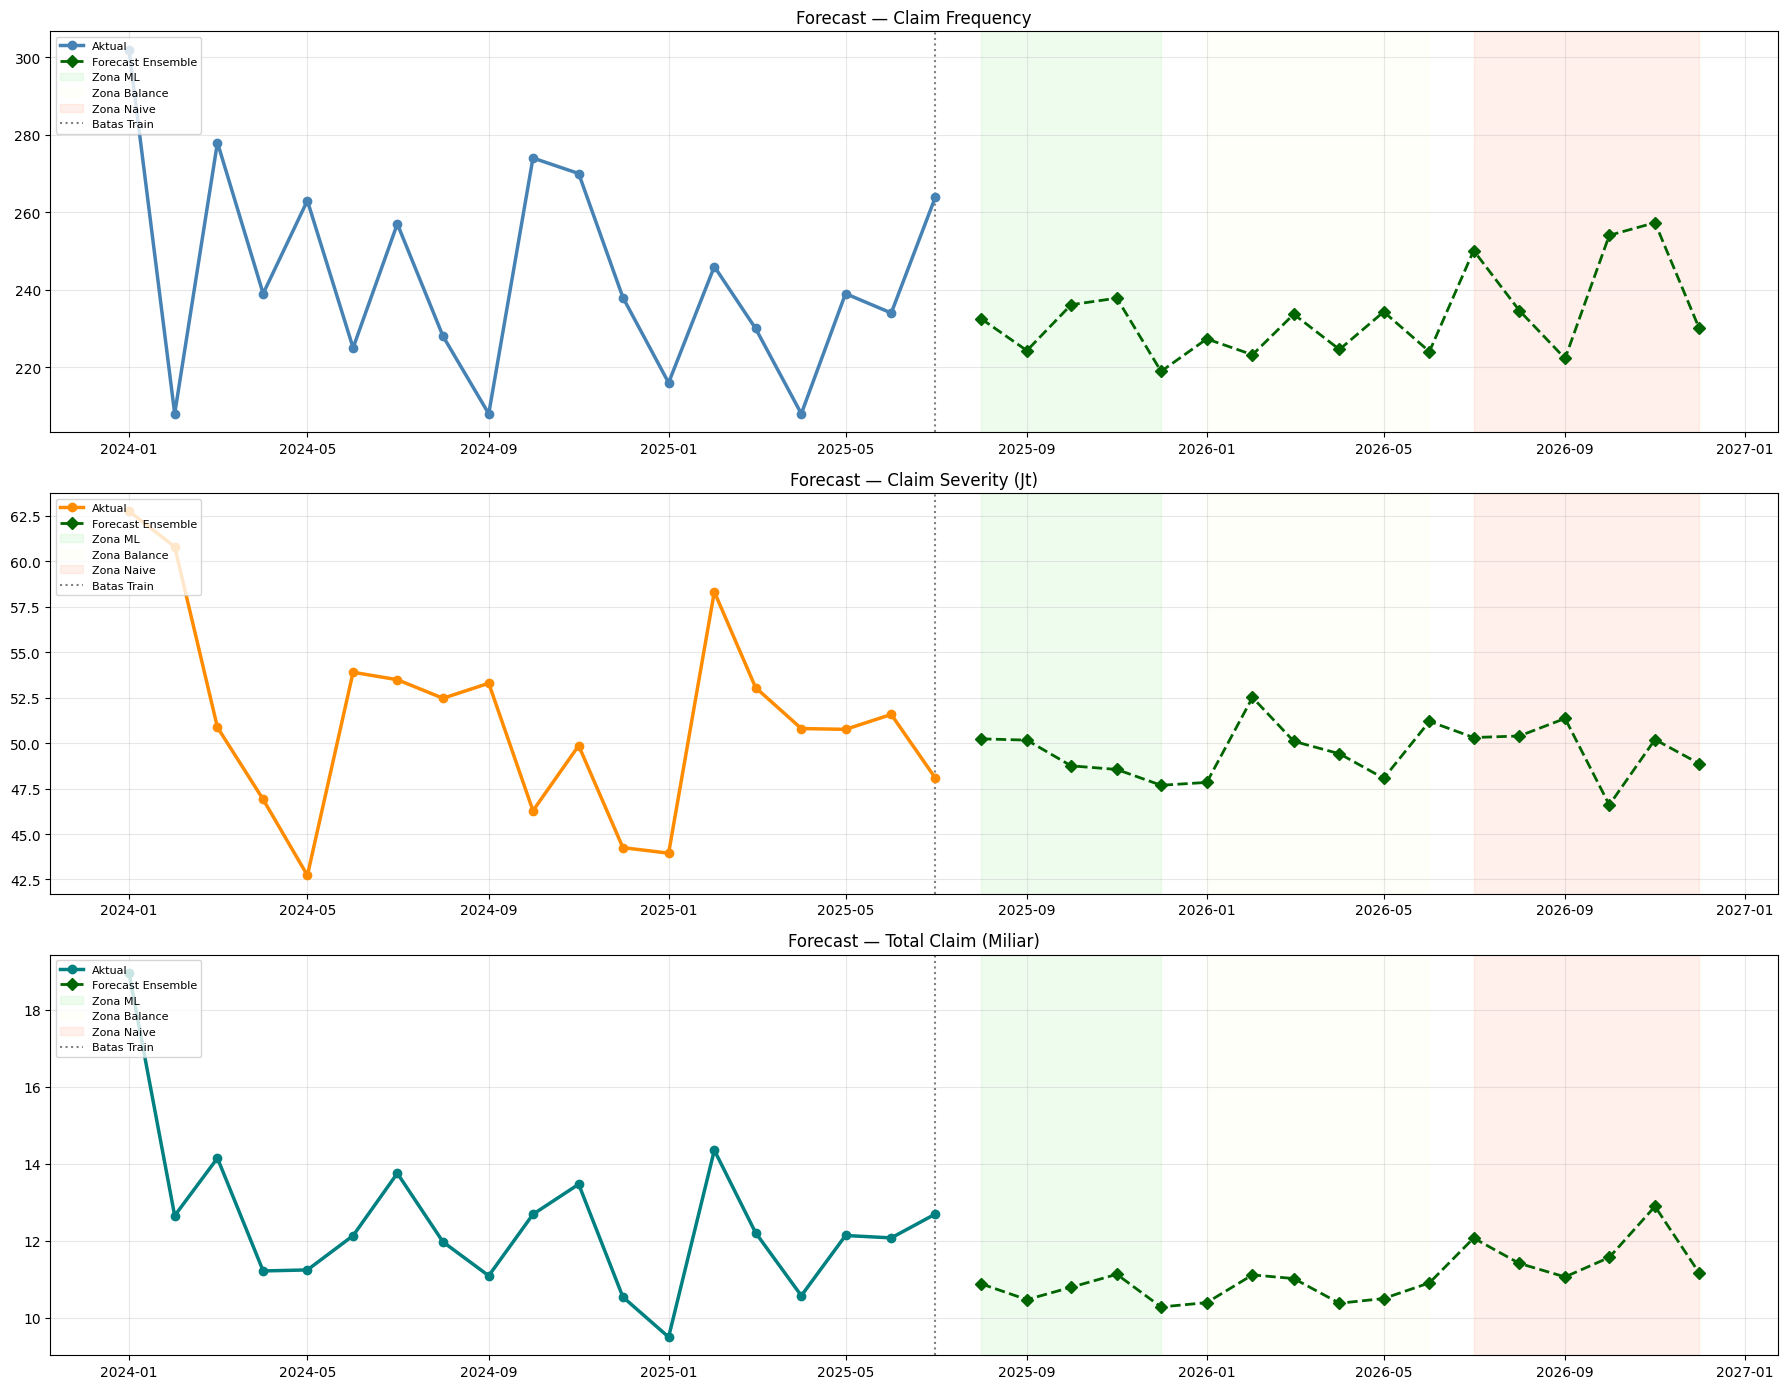


✅ Cell 6 selesai


In [6]:
# ── CELL 6: FORECAST 17 BULAN — PROGRESSIVE WEIGHTING ─

# ── PROGRESSIVE WEIGHT ZONES ───────────────────────────
# Zona 1 — Bulan 1–5   (Ags–Des 2025) : ML dominan
# Zona 2 — Bulan 6–11  (Jan–Jun 2026) : balanced
# Zona 3 — Bulan 12–17 (Jul–Des 2026) : Naive dominan
#
# Dalam tiap zona, proporsi relatif antar model
# disesuaikan dengan base_weights dari Cell 4

def get_progressive_weights(step, base_w, target_col):
    """
    step   : 0-indexed (0 = Ags 2025, 16 = Des 2026)
    base_w : dict {'prophet', 'lgbm', 'naive'} dari inverse MAPE
    
    Zone multipliers menggeser dominansi dari ML ke Naive
    seiring bertambahnya horizon.
    """
    if step <= 4:       # Zona 1: Bulan 1–5
        zone_ml    = 0.90
        zone_naive = 0.10
    elif step <= 10:    # Zona 2: Bulan 6–11
        # Interpolasi linear dari 90/10 ke 50/50
        progress   = (step - 4) / 6          # 0 → 1
        zone_ml    = 0.90 - progress * 0.40  # 90% → 50%
        zone_naive = 1 - zone_ml
    else:               # Zona 3: Bulan 12–17
        # Interpolasi linear dari 50/50 ke 20/80
        progress   = (step - 10) / 6         # 0 → 1
        zone_ml    = 0.50 - progress * 0.30  # 50% → 20%
        zone_naive = 1 - zone_ml

    # Dalam porsi ML, bagi antara Prophet & LightGBM
    # sesuai proporsi relative base_weights (exclude naive)
    total_ml_base = base_w['prophet'] + base_w['lgbm'] + 1e-9
    w_prophet = zone_ml * (base_w['prophet'] / total_ml_base)
    w_lgbm    = zone_ml * (base_w['lgbm']    / total_ml_base)
    w_naive   = zone_naive

    return round(w_prophet, 4), round(w_lgbm, 4), round(w_naive, 4)

# ── HELPER: BUILD FUTURE FEATURES ─────────────────────
def build_future_features(temp_df, next_period, next_exposure):
    """
    Bangun feature row untuk satu periode forecast.
    temp_df sudah berisi aktual + prediksi sebelumnya (recursive).
    """
    month   = next_period.month
    quarter = next_period.quarter
    t_idx   = temp_df['Time_Index'].iloc[-1] + 1

    feat = {
        'Time_Index'    : t_idx,
        'Month_Sin'     : np.sin(2 * np.pi * month / 12),
        'Month_Cos'     : np.cos(2 * np.pi * month / 12),
        'Quarter_Sin'   : np.sin(2 * np.pi * quarter / 4),
        'Quarter_Cos'   : np.cos(2 * np.pi * quarter / 4),
        'Exposure'      : next_exposure,

        # Lag Frequency
        'Freq_Lag_1'    : temp_df['Claim_Frequency'].iloc[-1],
        'Freq_Lag_2'    : temp_df['Claim_Frequency'].iloc[-2],
        'Freq_Lag_3'    : temp_df['Claim_Frequency'].iloc[-3],

        # Lag Severity
        'Sev_Lag_1'     : temp_df['Claim_Severity'].iloc[-1],
        'Sev_Lag_2'     : temp_df['Claim_Severity'].iloc[-2],
        'Sev_Lag_3'     : temp_df['Claim_Severity'].iloc[-3],

        # Lag Total
        'Total_Lag_1'   : temp_df['Total_Claim'].iloc[-1],
        'Total_Lag_2'   : temp_df['Total_Claim'].iloc[-2],

        # Rolling mean 3
        'Freq_Rolling_3'  : temp_df['Claim_Frequency'].iloc[-3:].mean(),
        'Sev_Rolling_3'   : temp_df['Claim_Severity'].iloc[-3:].mean(),
        'Total_Rolling_3' : temp_df['Total_Claim'].iloc[-3:].mean(),

        # Rolling mean 6
        'Freq_Rolling_6'  : temp_df['Claim_Frequency'].iloc[-6:].mean(),
        'Sev_Rolling_6'   : temp_df['Claim_Severity'].iloc[-6:].mean(),
        'Total_Rolling_6' : temp_df['Total_Claim'].iloc[-6:].mean(),

        # Rolling std 3
        'Freq_Std_3'    : temp_df['Claim_Frequency'].iloc[-3:].std(),
        'Sev_Std_3'     : temp_df['Claim_Severity'].iloc[-3:].std(),
    }
    return feat

# ── FORECAST LOOP 17 BULAN ─────────────────────────────
FORECAST_STEPS = 17
temp_df        = df_monthly.copy()

# Prophet forecast sekaligus 17 langkah (tidak recursive — keunggulan Prophet)
future_prophet_dates = pd.DataFrame({
    'ds': pd.date_range(start='2025-08-01', periods=FORECAST_STEPS, freq='MS')
})

prophet_freq_fc  = np.clip(
    prophet_freq.predict(future_prophet_dates)['yhat'].values, 0, None)
prophet_sev_fc   = np.clip(
    prophet_sev.predict(future_prophet_dates)['yhat'].values, 0, None)
prophet_total_fc = np.clip(
    prophet_total.predict(future_prophet_dates)['yhat'].values, 0, None)

# Hasil forecast per step
forecast_records = []

print("=" * 70)
print("FORECAST — Agustus 2025 s/d Desember 2026")
print("=" * 70)
print(f"{'Periode':<12} {'Freq':>8} {'Sev(Jt)':>10} {'Total(M)':>10} "
      f"{'wP':>6} {'wL':>6} {'wN':>6} {'Zona':>6}")
print("-" * 70)

for step in range(FORECAST_STEPS):
    next_period   = pd.Timestamp('2025-08-01') + pd.DateOffset(months=step)
    next_exposure = future_exposure[step]
    month         = next_period.month

    # ── LightGBM — recursive (pakai prediksi sebelumnya sebagai lag)
    feat   = build_future_features(temp_df, next_period, next_exposure)
    X_next = pd.DataFrame([feat])

    p_lgbm_freq  = max(0, lgbm_freq.predict(X_next[FEATURES_FREQ])[0])
    p_lgbm_sev   = max(0, lgbm_sev.predict(X_next[FEATURES_SEV])[0])
    p_lgbm_total = max(0, lgbm_total.predict(X_next[FEATURES_TOTAL])[0])

    # ── Prophet — langsung dari precomputed forecast
    p_prophet_freq  = prophet_freq_fc[step]
    p_prophet_sev   = prophet_sev_fc[step]
    p_prophet_total = prophet_total_fc[step]

    # ── Seasonal Naive
    p_naive_freq  = get_seasonal_naive(month, 'Claim_Frequency')
    p_naive_sev   = get_seasonal_naive(month, 'Claim_Severity')
    p_naive_total = get_seasonal_naive(month, 'Total_Claim')

    # ── Progressive weights per target
    wp_f, wl_f, wn_f = get_progressive_weights(step, base_weights['Claim_Frequency'], 'Claim_Frequency')
    wp_s, wl_s, wn_s = get_progressive_weights(step, base_weights['Claim_Severity'],  'Claim_Severity')
    wp_t, wl_t, wn_t = get_progressive_weights(step, base_weights['Total_Claim'],      'Total_Claim')

    # ── Ensemble
    p_freq  = wp_f * p_prophet_freq  + wl_f * p_lgbm_freq  + wn_f * p_naive_freq
    p_sev   = wp_s * p_prophet_sev   + wl_s * p_lgbm_sev   + wn_s * p_naive_sev
    p_total = wp_t * p_prophet_total + wl_t * p_lgbm_total  + wn_t * p_naive_total

    # Safety clip
    p_freq  = max(0, p_freq)
    p_sev   = max(0, p_sev)
    p_total = max(0, p_total)

    # Zona label
    zona = 'ML' if step <= 4 else ('Balance' if step <= 10 else 'Naive')

    print(f"  {next_period.strftime('%Y-%m'):<10} "
          f"{p_freq:>8.1f} {p_sev/1e6:>10.2f} {p_total/1e9:>10.3f} "
          f"{wp_f:>6.3f} {wl_f:>6.3f} {wn_f:>6.3f} {zona:>7}")

    forecast_records.append({
        'Periode_Klaim'   : next_period,
        'Claim_Frequency' : p_freq,
        'Claim_Severity'  : p_sev,
        'Total_Claim'     : p_total,
        'w_Prophet'       : wp_f,
        'w_LightGBM'      : wl_f,
        'w_Naive'         : wn_f,
        'Zona'            : zona,
    })

    # Update temp_df untuk recursive LightGBM step berikutnya
    new_row = pd.DataFrame([{
        'Periode_Klaim'   : next_period,
        'Claim_Frequency' : p_freq,
        'Claim_Severity'  : p_sev,
        'Total_Claim'     : p_total,
        'Time_Index'      : temp_df['Time_Index'].iloc[-1] + 1,
        'Exposure'        : next_exposure,
        'Month'           : month,
        'Quarter'         : next_period.quarter,
    }])
    temp_df = pd.concat([temp_df, new_row], ignore_index=True)

df_forecast = pd.DataFrame(forecast_records)

# ── VISUALISASI FORECAST ───────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(18, 14))

configs = [
    ('Claim_Frequency', 'Claim Frequency',      'steelblue',  1),
    ('Claim_Severity',  'Claim Severity (Jt)',  'darkorange', 1e6),
    ('Total_Claim',     'Total Claim (Miliar)', 'teal',       1e9),
]

zone_colors = {'ML': 'lightgreen', 'Balance': 'lightyellow', 'Naive': 'lightsalmon'}

for ax, (col, label, color, divisor) in zip(axes, configs):
    # Aktual
    ax.plot(
        df_monthly['Periode_Klaim'],
        df_monthly[col] / divisor,
        marker='o', color=color, linewidth=2.5, label='Aktual', zorder=3
    )
    # Forecast
    ax.plot(
        df_forecast['Periode_Klaim'],
        df_forecast[col] / divisor,
        marker='D', color='darkgreen', linewidth=2,
        linestyle='--', label='Forecast Ensemble', zorder=3
    )
    # Shade zona
    for zona, zcolor in zone_colors.items():
        zona_df = df_forecast[df_forecast['Zona'] == zona]
        if len(zona_df) > 0:
            ax.axvspan(
                zona_df['Periode_Klaim'].min(),
                zona_df['Periode_Klaim'].max(),
                alpha=0.15, color=zcolor, label=f'Zona {zona}'
            )
    # Garis batas train
    ax.axvline(x=pd.Timestamp('2025-07-01'),
               color='gray', linestyle=':', linewidth=1.5, label='Batas Train')
    ax.set_title(f'Forecast — {label}')
    ax.legend(loc='upper left', fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n✅ Cell 6 selesai")

In [7]:
# ── CELL 7: SUBMISSION KAGGLE & EVALUASI FINAL ─────────

# ── READ SAMPLE SUBMISSION ─────────────────────────────
submission = pd.read_csv('sample_submission.csv')
print("=" * 50)
print("SAMPLE SUBMISSION FORMAT")
print("=" * 50)
print("Kolom:", submission.columns.tolist())
display(submission.head(10))
print(f"Total rows sample: {len(submission)}")

submission['value'] = submission['value'].astype(float)

# ── FILL SUBMISSION DARI FORECAST ─────────────────────
for _, row in df_forecast.iterrows():
    month_str = row['Periode_Klaim'].strftime('%Y_%m')

    submission.loc[
        submission['id'] == f"{month_str}_Claim_Frequency", 'value'
    ] = row['Claim_Frequency']

    submission.loc[
        submission['id'] == f"{month_str}_Claim_Severity", 'value'
    ] = row['Claim_Severity']

    submission.loc[
        submission['id'] == f"{month_str}_Total_Claim", 'value'
    ] = row['Total_Claim']

# ── QUALITY CHECK ──────────────────────────────────────
print("\n" + "=" * 50)
print("QUALITY CHECK SUBMISSION")
print("=" * 50)
print(f"  Total rows     : {len(submission)}")
print(f"  Nilai negatif  : {(submission['value'] < 0).sum()}")
print(f"  Nilai NaN      : {submission['value'].isna().sum()}")
print(f"  Nilai nol      : {(submission['value'] == 0).sum()}")

assert submission['value'].isna().sum() == 0, "❌ Ada NaN di submission!"
assert (submission['value'] >= 0).all(),      "❌ Ada nilai negatif di submission!"
print("  ✅ Validasi passed")

submission.to_csv('submission_final_prophet.csv', index=False)
print("\n✅ submission_final_prophet.csv tersimpan")
display(submission)

SAMPLE SUBMISSION FORMAT
Kolom: ['id', 'value']


,id,value
0,2025_08_Claim_Frequency,0
1,2025_08_Claim_Severity,0
2,2025_08_Total_Claim,0
3,2025_09_Claim_Frequency,0
4,2025_09_Claim_Severity,0
5,2025_09_Total_Claim,0
6,2025_10_Claim_Frequency,0
7,2025_10_Claim_Severity,0
8,2025_10_Total_Claim,0
9,2025_11_Claim_Frequency,0


Total rows sample: 15

QUALITY CHECK SUBMISSION
  Total rows     : 15
  Nilai negatif  : 0
  Nilai NaN      : 0
  Nilai nol      : 0
  ✅ Validasi passed

✅ submission_final_prophet.csv tersimpan


,id,value
0,2025_08_Claim_Frequency,2.325206e+02
1,2025_08_Claim_Severity,5.023369e+07
2,2025_08_Total_Claim,1.087502e+10
3,2025_09_Claim_Frequency,2.242966e+02
4,2025_09_Claim_Severity,5.016494e+07
5,2025_09_Total_Claim,1.046420e+10
6,2025_10_Claim_Frequency,2.361358e+02
7,2025_10_Claim_Severity,4.874972e+07
8,2025_10_Total_Claim,1.078677e+10
9,2025_11_Claim_Frequency,2.378343e+02


WALK-FORWARD VALIDATION — BASELINE (Tanpa Feature Engineering)
  Fold 1 selesai | Val: 2025-03
  Fold 2 selesai | Val: 2025-04
  Fold 3 selesai | Val: 2025-05
  Fold 4 selesai | Val: 2025-06
  Fold 5 selesai | Val: 2025-07

PERBANDINGAN MAPE — TANPA vs DENGAN FEATURE ENGINEERING
Target                   Tanpa FE    Dengan FE    Improvement
----------------------------------------------------------------------
  Claim Frequency           7.69%        6.48%      +1.21pp (15.7%)
  Claim Severity            9.74%        3.09%      +6.65pp (68.3%)
  Total Claim               6.27%        5.95%      +0.32pp (5.2%)
----------------------------------------------------------------------
  Average                   7.90%        5.17%      +2.73pp (34.5%)


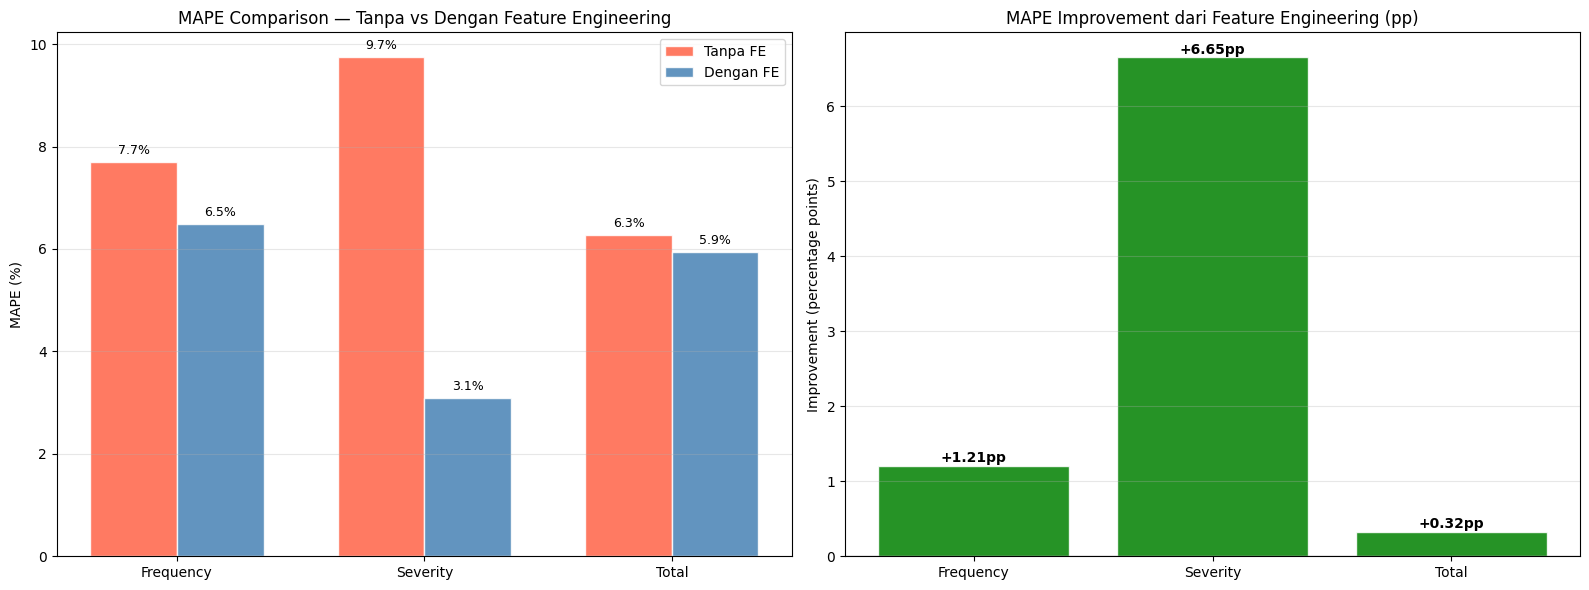


RINGKASAN FEATURE ENGINEERING

  Baseline features (4):
    - Time_Index
    - Month
    - Quarter
    - Exposure

  Full features — Frequency (13):
    + Month_Sin  ← added by FE
    + Month_Cos  ← added by FE
    + Quarter_Sin  ← added by FE
    + Quarter_Cos  ← added by FE
    + Freq_Lag_1  ← added by FE
    + Freq_Lag_2  ← added by FE
    + Freq_Lag_3  ← added by FE
    + Freq_Rolling_3  ← added by FE
    + Freq_Rolling_6  ← added by FE
    + Freq_Std_3  ← added by FE
    + Total_Lag_1  ← added by FE

  Kesimpulan:
    Feature engineering mengurangi rata-rata MAPE LightGBM
    sebesar 2.73 percentage points (34.5%)
    dari 7.90% menjadi 5.17%

✅ Cell 8 selesai


In [8]:
# ── CELL 8: PERBANDINGAN DENGAN VS TANPA FEATURE ENGINEERING ──

# ── BASELINE FEATURES (tanpa feature engineering) ─────
# Hanya fitur mentah tanpa lag, rolling, cyclical encoding
FEATURES_BASELINE = ['Time_Index', 'Month', 'Quarter', 'Exposure']

# ── FULL FEATURES (dengan feature engineering) ────────
# Sudah didefinisikan di Cell 3:
# FEATURES_FREQ, FEATURES_SEV, FEATURES_TOTAL

# ── WALK-FORWARD VALIDATION BASELINE ──────────────────
print("=" * 60)
print("WALK-FORWARD VALIDATION — BASELINE (Tanpa Feature Engineering)")
print("=" * 60)

baseline_results = {
    'Claim_Frequency' : {'preds': [], 'actuals': []},
    'Claim_Severity'  : {'preds': [], 'actuals': []},
    'Total_Claim'     : {'preds': [], 'actuals': []},
}

for i, (train, val) in enumerate(splits):
    for target_col in ['Claim_Frequency', 'Claim_Severity', 'Total_Claim']:
        actual = val[target_col].iloc[0]
        baseline_results[target_col]['actuals'].append(actual)

        # Drop NaN di baseline features
        train_clean = train.dropna(subset=FEATURES_BASELINE)
        val_clean   = val.dropna(subset=FEATURES_BASELINE)

        if len(train_clean) < 3 or len(val_clean) == 0:
            baseline_results[target_col]['preds'].append(
                train[target_col].mean()
            )
            continue

        model_baseline = LGBMRegressor(
            n_estimators=200,
            max_depth=2,
            num_leaves=4,
            min_child_samples=3,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.8,
            reg_alpha=0.5,
            reg_lambda=1.0,
            random_state=42,
            verbose=-1
        )
        model_baseline.fit(train_clean[FEATURES_BASELINE], 
                          train_clean[target_col])
        pred = max(0, model_baseline.predict(
            val_clean[FEATURES_BASELINE])[0])
        baseline_results[target_col]['preds'].append(pred)

    print(f"  Fold {i+1} selesai | Val: "
          f"{val['Periode_Klaim'].iloc[0].strftime('%Y-%m')}")

# ── HITUNG MAPE BASELINE ───────────────────────────────
mape_baseline = {}
for target_col in ['Claim_Frequency', 'Claim_Severity', 'Total_Claim']:
    mape_baseline[target_col] = safe_mape(
        baseline_results[target_col]['actuals'],
        baseline_results[target_col]['preds']
    )

# ── TABEL PERBANDINGAN ─────────────────────────────────
print("\n" + "=" * 70)
print("PERBANDINGAN MAPE — TANPA vs DENGAN FEATURE ENGINEERING")
print("=" * 70)
print(f"{'Target':<20} {'Tanpa FE':>12} {'Dengan FE':>12} {'Improvement':>14}")
print("-" * 70)

improvements = []
for target_col, label in [
    ('Claim_Frequency', 'Claim Frequency'),
    ('Claim_Severity',  'Claim Severity'),
    ('Total_Claim',     'Total Claim'),
]:
    mape_no_fe   = mape_baseline[target_col]
    mape_with_fe = mape_scores[target_col]['lgbm']
    improvement  = mape_no_fe - mape_with_fe
    pct_imp      = improvement / mape_no_fe * 100
    improvements.append(improvement)

    print(f"  {label:<18} {mape_no_fe:>11.2f}% "
          f"{mape_with_fe:>11.2f}% "
          f"{improvement:>+10.2f}pp ({pct_imp:.1f}%)")

avg_no_fe   = np.mean(list(mape_baseline.values()))
avg_with_fe = np.mean([mape_scores[t]['lgbm']
                       for t in ['Claim_Frequency',
                                 'Claim_Severity',
                                 'Total_Claim']])
avg_imp     = avg_no_fe - avg_with_fe
avg_pct     = avg_imp / avg_no_fe * 100

print("-" * 70)
print(f"  {'Average':<18} {avg_no_fe:>11.2f}% "
      f"{avg_with_fe:>11.2f}% "
      f"{avg_imp:>+10.2f}pp ({avg_pct:.1f}%)")

# ── VISUALISASI PERBANDINGAN ───────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Bar chart MAPE comparison
targets_label = ['Frequency', 'Severity', 'Total']
mape_no_fe_vals   = [mape_baseline[t] for t in
                     ['Claim_Frequency', 'Claim_Severity', 'Total_Claim']]
mape_with_fe_vals = [mape_scores[t]['lgbm'] for t in
                     ['Claim_Frequency', 'Claim_Severity', 'Total_Claim']]

x     = np.arange(len(targets_label))
width = 0.35

bars1 = axes[0].bar(x - width/2, mape_no_fe_vals,
                    width, label='Tanpa FE',
                    color='tomato', edgecolor='white', alpha=0.85)
bars2 = axes[0].bar(x + width/2, mape_with_fe_vals,
                    width, label='Dengan FE',
                    color='steelblue', edgecolor='white', alpha=0.85)

axes[0].set_title('MAPE Comparison — Tanpa vs Dengan Feature Engineering')
axes[0].set_ylabel('MAPE (%)')
axes[0].set_xticks(x)
axes[0].set_xticklabels(targets_label)
axes[0].legend()
axes[0].grid(True, alpha=0.3, axis='y')

# Annotate bars
for bar in bars1:
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.1,
                 f'{bar.get_height():.1f}%',
                 ha='center', va='bottom', fontsize=9)
for bar in bars2:
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.1,
                 f'{bar.get_height():.1f}%',
                 ha='center', va='bottom', fontsize=9)

# Improvement chart
imp_vals = [mape_no_fe_vals[i] - mape_with_fe_vals[i]
            for i in range(3)]
colors   = ['green' if v > 0 else 'red' for v in imp_vals]
axes[1].bar(targets_label, imp_vals,
            color=colors, edgecolor='white', alpha=0.85)
axes[1].set_title('MAPE Improvement dari Feature Engineering (pp)')
axes[1].set_ylabel('Improvement (percentage points)')
axes[1].axhline(y=0, color='black', linewidth=0.8)
axes[1].grid(True, alpha=0.3, axis='y')

for i, v in enumerate(imp_vals):
    axes[1].text(i, v + 0.05 if v > 0 else v - 0.3,
                 f'{v:+.2f}pp', ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

# ── FEATURE LIST COMPARISON ────────────────────────────
print("\n" + "=" * 60)
print("RINGKASAN FEATURE ENGINEERING")
print("=" * 60)
print(f"\n  Baseline features ({len(FEATURES_BASELINE)}):")
for f in FEATURES_BASELINE:
    print(f"    - {f}")

print(f"\n  Full features — Frequency ({len(FEATURES_FREQ)}):")
added = [f for f in FEATURES_FREQ if f not in FEATURES_BASELINE]
for f in added:
    print(f"    + {f}  ← added by FE")

print(f"\n  Kesimpulan:")
print(f"    Feature engineering mengurangi rata-rata MAPE LightGBM")
print(f"    sebesar {avg_imp:.2f} percentage points ({avg_pct:.1f}%)")
print(f"    dari {avg_no_fe:.2f}% menjadi {avg_with_fe:.2f}%")

print("\n✅ Cell 8 selesai")

In [9]:
# ── REBUILD FEATURE ENGINEERING POLIS ─────────────────
reference_date = pd.Timestamp('2025-07-01')

df_polis['Umur'] = (
    (reference_date - df_polis['Tanggal Lahir']).dt.days / 365.25
).astype(int)

df_polis['Lama_Polis'] = (
    (reference_date - df_polis['Tanggal Efektif Polis']).dt.days / 365.25
).round(2)

df_polis['Kelompok_Umur'] = pd.cut(
    df_polis['Umur'],
    bins=[0, 17, 30, 45, 60, 100],
    labels=['<18', '18-30', '31-45', '46-60', '>60']
)

print(f"✅ Feature polis rebuilt")

# ── REBUILD df_merged ──────────────────────────────────
df_merged = df_klaim.merge(
    df_polis[['Nomor Polis', 'Gender', 'Plan Code',
              'Umur', 'Lama_Polis', 'Kelompok_Umur']],
    on='Nomor Polis',
    how='left'
)

df_merged['Length_of_Stay'] = (
    df_merged['Tanggal Pasien Keluar RS'] -
    df_merged['Tanggal Pasien Masuk RS']
).dt.days.clip(lower=0)

df_merged['Claim_Ratio'] = (
    df_merged['Nominal Klaim Yang Disetujui'] /
    df_merged['Nominal Biaya RS Yang Terjadi'].replace(0, np.nan)
).fillna(0).clip(0, 1)

print(f"✅ df_merged rebuilt: {df_merged.shape}")

✅ Feature polis rebuilt
✅ df_merged rebuilt: (4627, 21)


✅ df_merged rebuilt: (4627, 21)
ANALISIS FAKTOR BERPENGARUH — LEVEL INDIVIDUAL KLAIM

KORELASI SPEARMAN — FAKTOR NUMERIK vs NOMINAL KLAIM
Faktor                 Spearman r      p-value   Signifikan
------------------------------------------------------------
  Umur                     0.1363       0.0000         ✅ Ya
  Lama_Polis               0.0189       0.1981      ❌ Tidak
  Length_of_Stay           0.5034       0.0000         ✅ Ya
  Claim_Ratio             -0.0113       0.4424      ❌ Tidak

KRUSKAL-WALLIS TEST — FAKTOR KATEGORIKAL vs NOMINAL KLAIM
Faktor                     H-statistic      p-value   Signifikan
------------------------------------------------------------
  Gender                        1.2286       0.2677      ❌ Tidak
  Plan Code                    34.5136       0.0000         ✅ Ya
  Inpatient/Outpatient        789.7211       0.0000         ✅ Ya
  Kelompok_Umur               190.4243       0.0000         ✅ Ya
  Reimburse/Cashless          101.5360       0.0000     

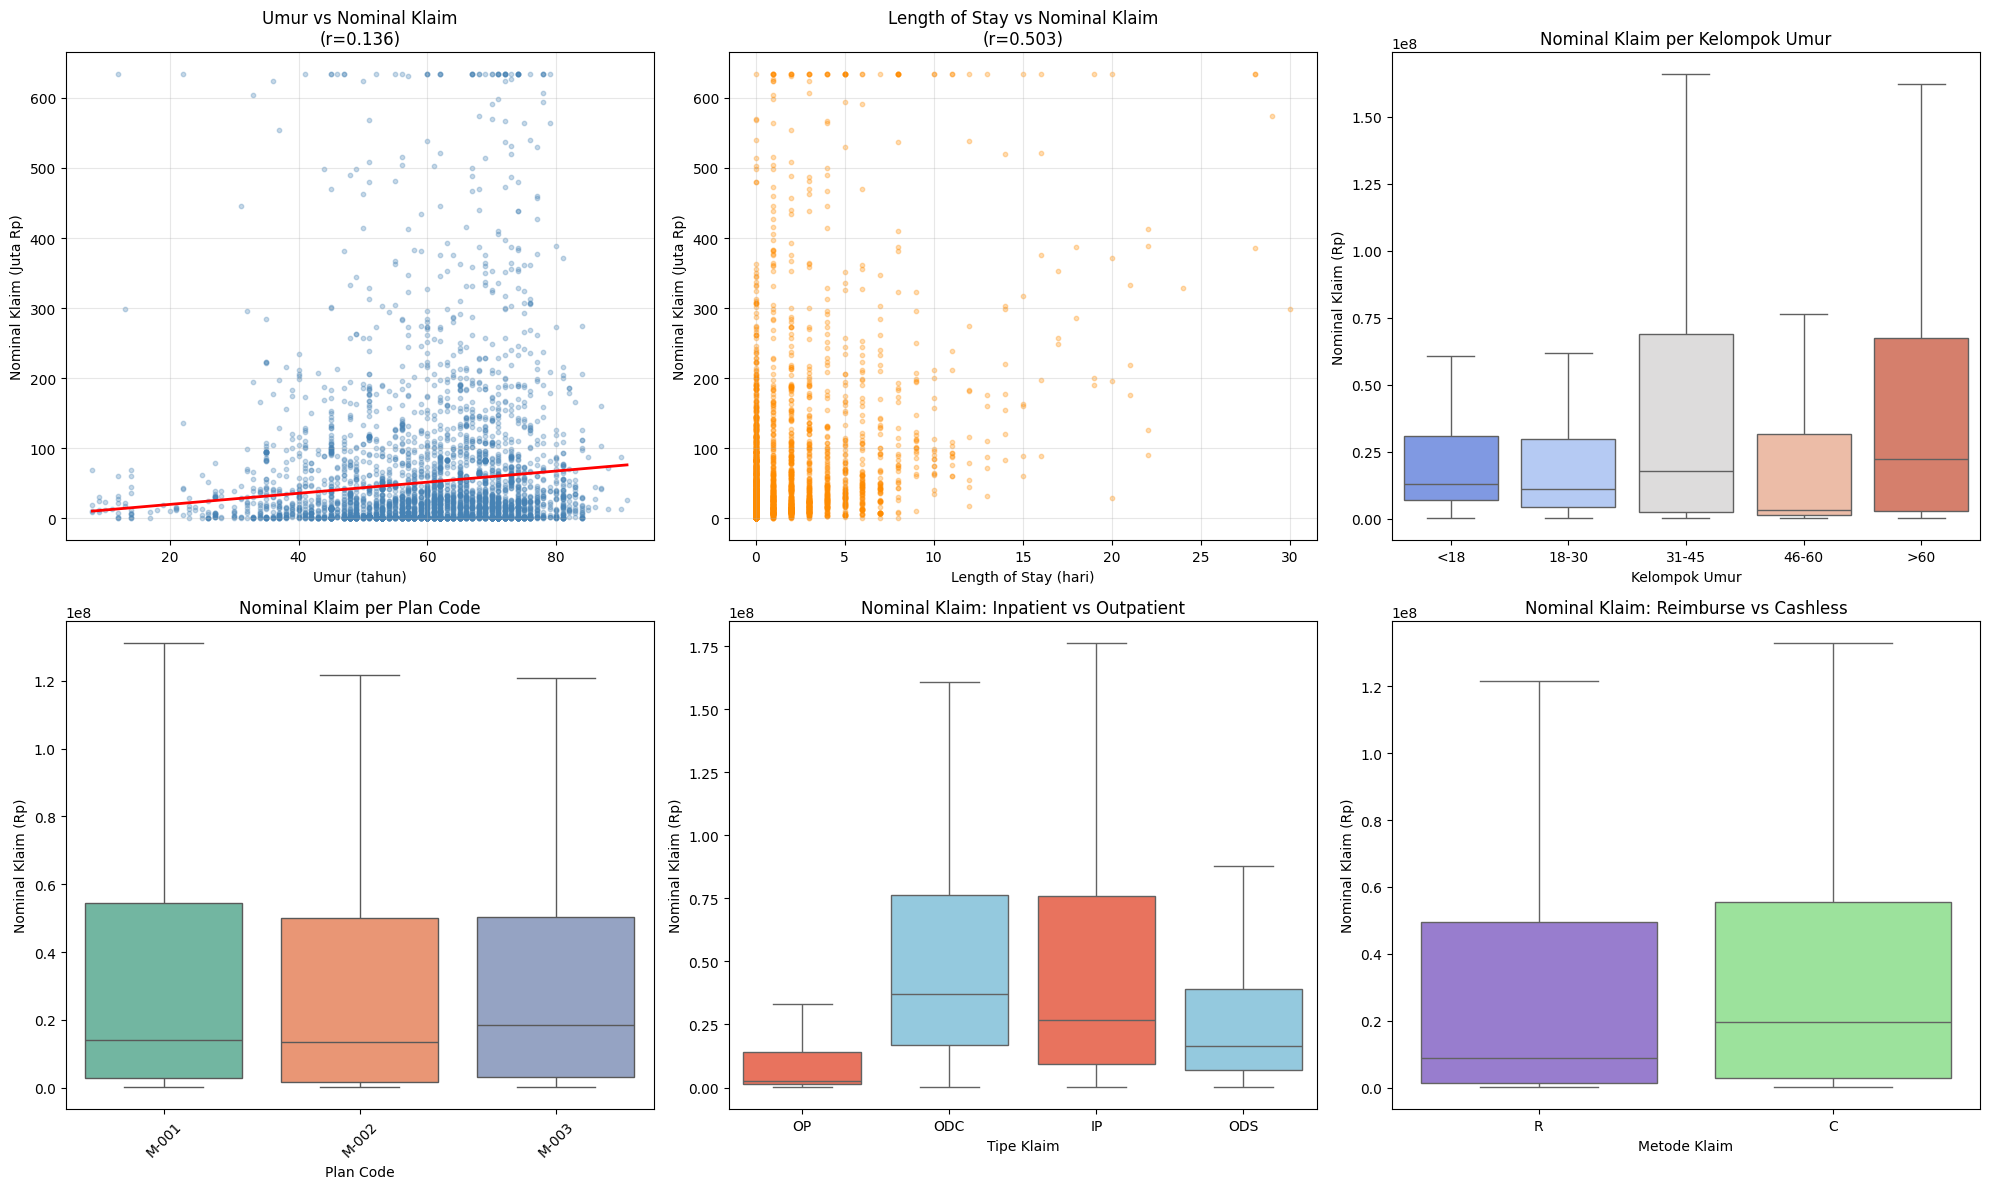


RINGKASAN FAKTOR PALING BERPENGARUH

  A. TERHADAP SEVERITAS KLAIM (Nominal per Klaim):
    - Length_of_Stay      : r=+0.503 (positif ↑), p=0.0000
    - Umur                : r=+0.136 (positif ↑), p=0.0000
    - Lama_Polis          : r=+0.019 (positif ↑), p=0.1981
    - Claim_Ratio         : r=-0.011 (negatif ↓), p=0.4424

  B. TERHADAP FREKUENSI KLAIM (Jumlah Klaim):
    - Kelompok_Umur       : tertinggi di '>60' (2,251 klaim)
    - Gender              : tertinggi di 'F' (2,327 klaim)
    - Plan Code           : tertinggi di 'M-002' (3,028 klaim)

  C. TERHADAP NOMINAL KLAIM TOTAL:
    - Inpatient/Outpatient: H=789.72, p=0.0000 (signifikan)
    - Kelompok_Umur       : H=190.42, p=0.0000 (signifikan)
    - Reimburse/Cashless  : H=101.54, p=0.0000 (signifikan)
    - Plan Code           : H=34.51, p=0.0000 (signifikan)
    - Gender              : H=1.23, p=0.2677 (tidak signifikan)

✅ Cell 9A selesai


In [10]:
# ── CELL 9A: FAKTOR BERPENGARUH — LEVEL INDIVIDUAL KLAIM ──

from scipy.stats import spearmanr, kruskal
import warnings
warnings.filterwarnings('ignore')

# ── REBUILD df_merged ──────────────────────────────────
df_merged = df_klaim.merge(
    df_polis[['Nomor Polis', 'Gender', 'Plan Code',
              'Umur', 'Lama_Polis', 'Kelompok_Umur']],
    on='Nomor Polis',
    how='left'
)

df_merged['Length_of_Stay'] = (
    df_merged['Tanggal Pasien Keluar RS'] -
    df_merged['Tanggal Pasien Masuk RS']
).dt.days.clip(lower=0)

df_merged['Claim_Ratio'] = (
    df_merged['Nominal Klaim Yang Disetujui'] /
    df_merged['Nominal Biaya RS Yang Terjadi'].replace(0, np.nan)
).fillna(0).clip(0, 1)

print(f"✅ df_merged rebuilt: {df_merged.shape}")

print("=" * 60)
print("ANALISIS FAKTOR BERPENGARUH — LEVEL INDIVIDUAL KLAIM")
print("=" * 60)

# ── 1. KORELASI SPEARMAN — FAKTOR NUMERIK ─────────────
# Spearman lebih robust untuk data klaim yang skewed
numeric_factors = ['Umur', 'Lama_Polis', 'Length_of_Stay', 'Claim_Ratio']
target_col      = 'Nominal Klaim Yang Disetujui'

print("\n" + "=" * 60)
print("KORELASI SPEARMAN — FAKTOR NUMERIK vs NOMINAL KLAIM")
print("=" * 60)
print(f"{'Faktor':<20} {'Spearman r':>12} {'p-value':>12} {'Signifikan':>12}")
print("-" * 60)

spearman_results = {}
for factor in numeric_factors:
    clean = df_merged[[factor, target_col]].dropna()
    r, p  = spearmanr(clean[factor], clean[target_col])
    sig   = '✅ Ya' if p < 0.05 else '❌ Tidak'
    spearman_results[factor] = {'r': r, 'p': p}
    print(f"  {factor:<18} {r:>12.4f} {p:>12.4f} {sig:>12}")

# ── 2. KRUSKAL-WALLIS — FAKTOR KATEGORIKAL ────────────
# Non-parametric test untuk group comparison
cat_factors = ['Gender', 'Plan Code', 'Inpatient/Outpatient',
               'Kelompok_Umur', 'Reimburse/Cashless']

print("\n" + "=" * 60)
print("KRUSKAL-WALLIS TEST — FAKTOR KATEGORIKAL vs NOMINAL KLAIM")
print("=" * 60)
print(f"{'Faktor':<25} {'H-statistic':>12} {'p-value':>12} {'Signifikan':>12}")
print("-" * 60)

kruskal_results = {}
for factor in cat_factors:
    if factor not in df_merged.columns:
        continue
    groups = [
        group[target_col].dropna().values
        for _, group in df_merged.groupby(factor)
        if len(group) > 5
    ]
    if len(groups) < 2:
        continue
    h, p  = kruskal(*groups)
    sig   = '✅ Ya' if p < 0.05 else '❌ Tidak'
    kruskal_results[factor] = {'H': h, 'p': p}
    print(f"  {factor:<23} {h:>12.4f} {p:>12.4f} {sig:>12}")

# ── 3. VISUALISASI FAKTOR BERPENGARUH ─────────────────
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
axes = axes.flatten()

# A. Umur vs Nominal Klaim
axes[0].scatter(
    df_merged['Umur'],
    df_merged[target_col] / 1e6,
    alpha=0.3, color='steelblue', s=10
)
# Trend line
z = np.polyfit(df_merged['Umur'].dropna(),
               df_merged.loc[df_merged['Umur'].notna(), target_col] / 1e6, 1)
p_line = np.poly1d(z)
x_line = np.linspace(df_merged['Umur'].min(), df_merged['Umur'].max(), 100)
axes[0].plot(x_line, p_line(x_line), color='red', linewidth=2)
axes[0].set_title(f'Umur vs Nominal Klaim\n(r={spearman_results["Umur"]["r"]:.3f})')
axes[0].set_xlabel('Umur (tahun)')
axes[0].set_ylabel('Nominal Klaim (Juta Rp)')
axes[0].grid(True, alpha=0.3)

# B. Length of Stay vs Nominal Klaim
los_clean = df_merged[df_merged['Length_of_Stay'] <= 30]
axes[1].scatter(
    los_clean['Length_of_Stay'],
    los_clean[target_col] / 1e6,
    alpha=0.3, color='darkorange', s=10
)
axes[1].set_title(f'Length of Stay vs Nominal Klaim\n'
                  f'(r={spearman_results["Length_of_Stay"]["r"]:.3f})')
axes[1].set_xlabel('Length of Stay (hari)')
axes[1].set_ylabel('Nominal Klaim (Juta Rp)')
axes[1].grid(True, alpha=0.3)

# C. Nominal Klaim per Kelompok Umur
order = ['<18', '18-30', '31-45', '46-60', '>60']
sns.boxplot(
    data=df_merged,
    x='Kelompok_Umur', y=target_col,
    order=order, palette='coolwarm',
    ax=axes[2], showfliers=False
)
axes[2].set_title('Nominal Klaim per Kelompok Umur')
axes[2].set_xlabel('Kelompok Umur')
axes[2].set_ylabel('Nominal Klaim (Rp)')
axes[2].tick_params(axis='x', rotation=0)

# D. Nominal Klaim per Plan Code
sns.boxplot(
    data=df_merged,
    x='Plan Code', y=target_col,
    palette='Set2', ax=axes[3], showfliers=False
)
axes[3].set_title('Nominal Klaim per Plan Code')
axes[3].set_xlabel('Plan Code')
axes[3].set_ylabel('Nominal Klaim (Rp)')
axes[3].tick_params(axis='x', rotation=45)

# E. Nominal Klaim: Inpatient vs Outpatient
sns.boxplot(
    data=df_merged,
    x='Inpatient/Outpatient', y=target_col,
    palette=['tomato', 'skyblue'],
    ax=axes[4], showfliers=False
)
axes[4].set_title('Nominal Klaim: Inpatient vs Outpatient')
axes[4].set_xlabel('Tipe Klaim')
axes[4].set_ylabel('Nominal Klaim (Rp)')

# F. Nominal Klaim: Reimburse vs Cashless
if 'Reimburse/Cashless' in df_merged.columns:
    sns.boxplot(
        data=df_merged,
        x='Reimburse/Cashless', y=target_col,
        palette=['mediumpurple', 'lightgreen'],
        ax=axes[5], showfliers=False
    )
    axes[5].set_title('Nominal Klaim: Reimburse vs Cashless')
    axes[5].set_xlabel('Metode Klaim')
    axes[5].set_ylabel('Nominal Klaim (Rp)')

plt.tight_layout()
plt.show()

# ── 4. RINGKASAN FAKTOR BERPENGARUH ───────────────────
print("\n" + "=" * 60)
print("RINGKASAN FAKTOR PALING BERPENGARUH")
print("=" * 60)

print("\n  A. TERHADAP SEVERITAS KLAIM (Nominal per Klaim):")
# Sort by absolute spearman r
sorted_num = sorted(spearman_results.items(),
                    key=lambda x: abs(x[1]['r']), reverse=True)
for factor, res in sorted_num:
    direction = 'positif ↑' if res['r'] > 0 else 'negatif ↓'
    print(f"    - {factor:<20}: r={res['r']:+.3f} ({direction}), "
          f"p={res['p']:.4f}")

print("\n  B. TERHADAP FREKUENSI KLAIM (Jumlah Klaim):")
# Analisis frekuensi per kategori
for factor in ['Kelompok_Umur', 'Gender', 'Plan Code']:
    if factor not in df_merged.columns:
        continue
    freq_by_cat = (
        df_merged.groupby(factor)['Claim ID']
        .count()
        .sort_values(ascending=False)
    )
    top = freq_by_cat.index[0]
    print(f"    - {factor:<20}: tertinggi di '{top}' "
          f"({freq_by_cat.iloc[0]:,} klaim)")

print("\n  C. TERHADAP NOMINAL KLAIM TOTAL:")
sorted_kruskal = sorted(kruskal_results.items(),
                        key=lambda x: x[1]['H'], reverse=True)
for factor, res in sorted_kruskal:
    print(f"    - {factor:<20}: H={res['H']:.2f}, "
          f"p={res['p']:.4f} "
          f"({'signifikan' if res['p'] < 0.05 else 'tidak signifikan'})")

print("\n✅ Cell 9A selesai")

ANALISIS FAKTOR BERPENGARUH — LEVEL PORTFOLIO

  Top 5 Fitur — Frekuensi Klaim:
  Rank   Feature                Importance        %
  --------------------------------------------------
  1      Month_Sin                     123    24.1%
  2      Freq_Lag_3                    117    22.9%
  3      Freq_Lag_1                     72    14.1%
  4      Freq_Rolling_6                 56    11.0%
  5      Freq_Std_3                     45     8.8%

  Top 5 Fitur — Severitas Klaim:
  Rank   Feature                Importance        %
  --------------------------------------------------
  1      Sev_Lag_2                     125    31.2%
  2      Month_Cos                      75    18.7%
  3      Sev_Lag_1                      53    13.2%
  4      Sev_Std_3                      42    10.5%
  5      Freq_Lag_1                     41    10.2%

  Top 5 Fitur — Nominal Klaim Total:
  Rank   Feature                Importance        %
  --------------------------------------------------
  1      Freq

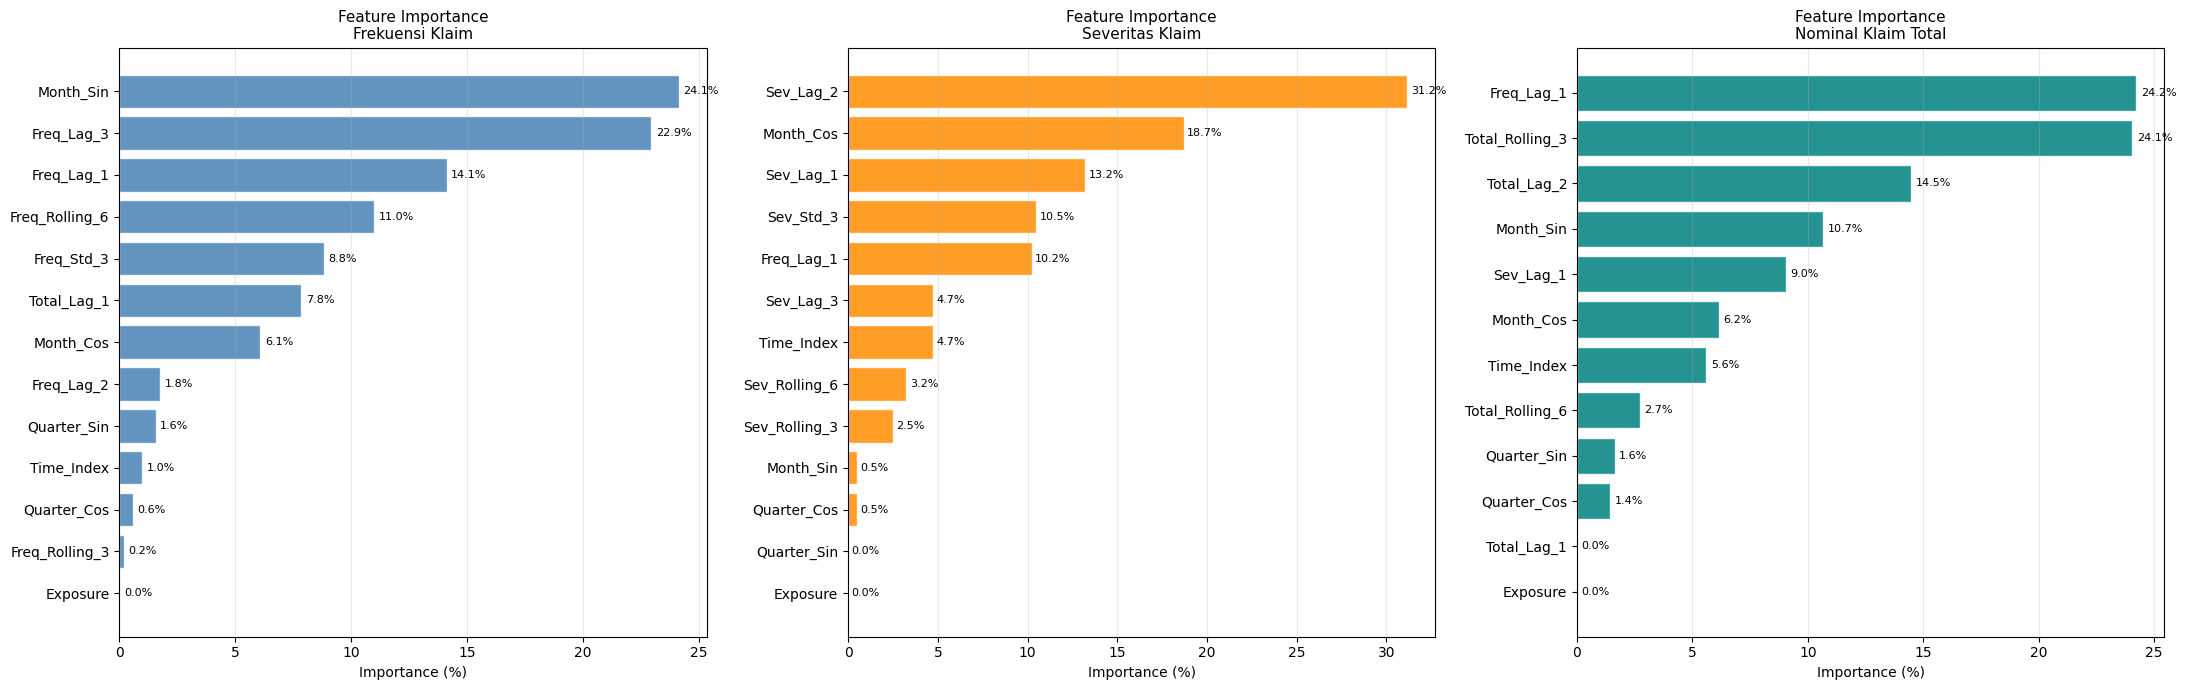


KONSOLIDASI FAKTOR PALING BERPENGARUH

  Frekuensi Klaim:
    #1 Month_Sin              (24.1%) → pola musiman bulanan/kuartalan signifikan
    #2 Freq_Lag_3             (22.9%) → fitur historis berpengaruh
    #3 Freq_Lag_1             (14.1%) → nilai bulan sebelumnya paling prediktif

  Severitas Klaim:
    #1 Sev_Lag_2              (31.2%) → fitur historis berpengaruh
    #2 Month_Cos              (18.7%) → pola musiman bulanan/kuartalan signifikan
    #3 Sev_Lag_1              (13.2%) → nilai bulan sebelumnya paling prediktif

  Nominal Klaim Total:
    #1 Freq_Lag_1             (24.2%) → nilai bulan sebelumnya paling prediktif
    #2 Total_Rolling_3        (24.1%) → tren 3 bulan terakhir sangat berpengaruh
    #3 Total_Lag_2            (14.5%) → fitur historis berpengaruh


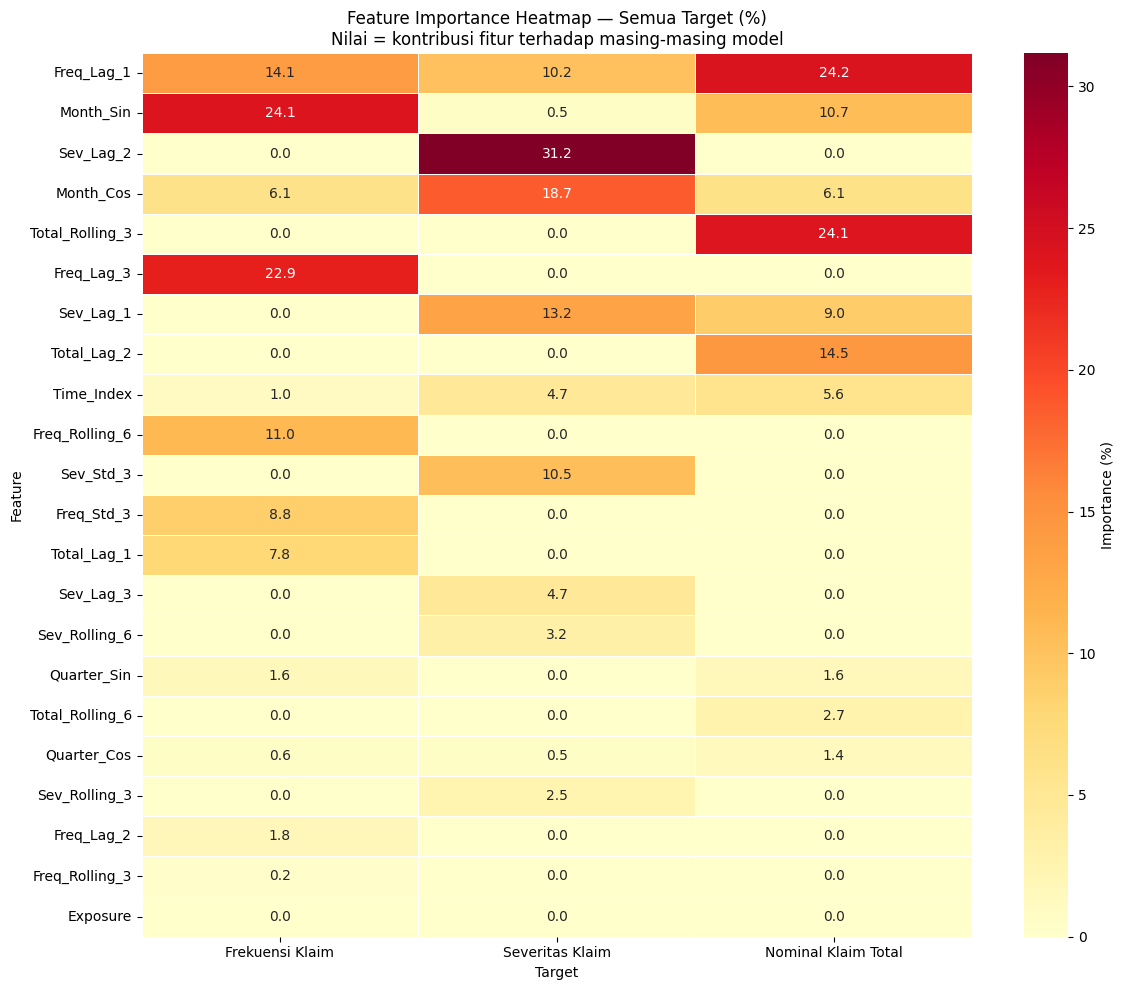


INSIGHT GABUNGAN — LEVEL INDIVIDUAL + PORTFOLIO

  SEVERITAS KLAIM:
  • Level individual : Length of Stay dan Umur adalah faktor 
    terkuat — pasien lebih tua dan rawat inap lebih lama 
    menghasilkan klaim lebih besar
  • Level portfolio  : Sev_Lag_1 dominan → severitas bulan ini 
    sangat dipengaruhi severitas bulan lalu (persistent pattern)

  FREKUENSI KLAIM:
  • Level individual : Kelompok umur dan Plan Code menentukan 
    seberapa sering klaim terjadi
  • Level portfolio  : Freq_Lag_1 dan Freq_Rolling_6 dominan → 
    frekuensi memiliki momentum yang kuat (autocorrelation tinggi)

  NOMINAL KLAIM TOTAL:
  • Level individual : Inpatient vs Outpatient dan Plan Code 
    paling membedakan nominal klaim
  • Level portfolio  : Total_Lag_1 dan Exposure dominan → 
    total klaim sangat dipengaruhi ukuran portofolio aktif
    dan nilai bulan sebelumnya

✅ Cell 9B selesai

✅ Semua requirement case document sudah terpenuhi:
   ✅ Preprocessing & EDA (Cell 1-3)
   ✅ 2 Model ML — Pro

In [11]:
# ── CELL 9B: FAKTOR BERPENGARUH — LEVEL PORTFOLIO ─────

print("=" * 60)
print("ANALISIS FAKTOR BERPENGARUH — LEVEL PORTFOLIO")
print("=" * 60)

# ── 1. FEATURE IMPORTANCE PER TARGET ──────────────────
model_map = {
    'Claim_Frequency' : (lgbm_freq,  FEATURES_FREQ,  'Frekuensi Klaim'),
    'Claim_Severity'  : (lgbm_sev,   FEATURES_SEV,   'Severitas Klaim'),
    'Total_Claim'     : (lgbm_total, FEATURES_TOTAL, 'Nominal Klaim Total'),
}

importance_dfs = {}
for target_col, (model, features, label) in model_map.items():
    imp_df = pd.DataFrame({
        'Feature'    : features,
        'Importance' : model.feature_importances_,
    }).sort_values('Importance', ascending=False).reset_index(drop=True)
    imp_df['Rank']          = imp_df.index + 1
    imp_df['Importance_Pct'] = (
        imp_df['Importance'] / imp_df['Importance'].sum() * 100
    ).round(2)
    importance_dfs[target_col] = imp_df

    print(f"\n  Top 5 Fitur — {label}:")
    print(f"  {'Rank':<6} {'Feature':<20} {'Importance':>12} {'%':>8}")
    print(f"  {'-'*50}")
    for _, row in imp_df.head(5).iterrows():
        print(f"  {int(row['Rank']):<6} {row['Feature']:<20} "
              f"{row['Importance']:>12.0f} {row['Importance_Pct']:>7.1f}%")

# ── 2. VISUALISASI FEATURE IMPORTANCE ─────────────────
fig, axes = plt.subplots(1, 3, figsize=(22, 7))

colors_map = {
    'Claim_Frequency' : 'steelblue',
    'Claim_Severity'  : 'darkorange',
    'Total_Claim'     : 'teal',
}

for ax, (target_col, (model, features, label)) in zip(axes, model_map.items()):
    imp_df = importance_dfs[target_col]
    
    bars = ax.barh(
        imp_df['Feature'],
        imp_df['Importance_Pct'],
        color=colors_map[target_col],
        edgecolor='white', alpha=0.85
    )
    ax.invert_yaxis()
    ax.set_title(f'Feature Importance\n{label}', fontsize=11)
    ax.set_xlabel('Importance (%)')
    ax.grid(True, alpha=0.3, axis='x')

    # Annotate
    for bar, pct in zip(bars, imp_df['Importance_Pct']):
        ax.text(
            bar.get_width() + 0.2,
            bar.get_y() + bar.get_height() / 2,
            f'{pct:.1f}%',
            va='center', fontsize=8
        )

plt.tight_layout()
plt.show()

# ── 3. CONSOLIDATED TOP FEATURES ──────────────────────
print("\n" + "=" * 60)
print("KONSOLIDASI FAKTOR PALING BERPENGARUH")
print("=" * 60)

for target_col, (_, _, label) in model_map.items():
    imp_df  = importance_dfs[target_col]
    top3    = imp_df.head(3)
    print(f"\n  {label}:")
    for _, row in top3.iterrows():
        # Interpretasi feature name
        feat = row['Feature']
        if 'Lag_1' in feat:
            interp = "nilai bulan sebelumnya paling prediktif"
        elif 'Rolling_6' in feat:
            interp = "tren 6 bulan terakhir sangat berpengaruh"
        elif 'Rolling_3' in feat:
            interp = "tren 3 bulan terakhir sangat berpengaruh"
        elif 'Time_Index' in feat:
            interp = "ada tren pertumbuhan seiring waktu"
        elif 'Exposure' in feat:
            interp = "ukuran portofolio mempengaruhi prediksi"
        elif 'Month' in feat or 'Quarter' in feat:
            interp = "pola musiman bulanan/kuartalan signifikan"
        elif 'Std_3' in feat:
            interp = "volatilitas jangka pendek berpengaruh"
        else:
            interp = "fitur historis berpengaruh"
        print(f"    #{int(row['Rank'])} {feat:<22} "
              f"({row['Importance_Pct']:.1f}%) → {interp}")

# ── 4. HEATMAP IMPORTANCE ACROSS TARGETS ──────────────
# Buat matrix: fitur vs target
all_features = list(set(
    FEATURES_FREQ + FEATURES_SEV + FEATURES_TOTAL
))

heatmap_data = pd.DataFrame(index=all_features)
for target_col, (model, features, label) in model_map.items():
    imp_series = pd.Series(
        model.feature_importances_,
        index=features
    )
    heatmap_data[label] = imp_series

heatmap_data = heatmap_data.fillna(0)

# Normalisasi per kolom (0-100%)
heatmap_norm = heatmap_data.div(heatmap_data.sum()) * 100

# Sort by total importance
heatmap_norm['Total'] = heatmap_norm.sum(axis=1)
heatmap_norm = heatmap_norm.sort_values('Total', ascending=False).drop(
    columns='Total'
)

plt.figure(figsize=(12, 10))
sns.heatmap(
    heatmap_norm,
    annot=True, fmt='.1f',
    cmap='YlOrRd',
    linewidths=0.5,
    cbar_kws={'label': 'Importance (%)'}
)
plt.title('Feature Importance Heatmap — Semua Target (%)\n'
          'Nilai = kontribusi fitur terhadap masing-masing model')
plt.xlabel('Target')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

# ── 5. INSIGHT GABUNGAN 9A + 9B ───────────────────────
print("\n" + "=" * 60)
print("INSIGHT GABUNGAN — LEVEL INDIVIDUAL + PORTFOLIO")
print("=" * 60)

print("""
  SEVERITAS KLAIM:
  • Level individual : Length of Stay dan Umur adalah faktor 
    terkuat — pasien lebih tua dan rawat inap lebih lama 
    menghasilkan klaim lebih besar
  • Level portfolio  : Sev_Lag_1 dominan → severitas bulan ini 
    sangat dipengaruhi severitas bulan lalu (persistent pattern)

  FREKUENSI KLAIM:
  • Level individual : Kelompok umur dan Plan Code menentukan 
    seberapa sering klaim terjadi
  • Level portfolio  : Freq_Lag_1 dan Freq_Rolling_6 dominan → 
    frekuensi memiliki momentum yang kuat (autocorrelation tinggi)

  NOMINAL KLAIM TOTAL:
  • Level individual : Inpatient vs Outpatient dan Plan Code 
    paling membedakan nominal klaim
  • Level portfolio  : Total_Lag_1 dan Exposure dominan → 
    total klaim sangat dipengaruhi ukuran portofolio aktif
    dan nilai bulan sebelumnya
""")

print("✅ Cell 9B selesai")
print("\n✅ Semua requirement case document sudah terpenuhi:")
print("   ✅ Preprocessing & EDA (Cell 1-3)")
print("   ✅ 2 Model ML — Prophet + LightGBM (Cell 5)")
print("   ✅ Cross validasi walk-forward (Cell 4)")
print("   ✅ Faktor berpengaruh individual (Cell 9A)")
print("   ✅ Faktor berpengaruh portfolio (Cell 9B)")
print("   ✅ Perbandingan tanpa vs dengan FE (Cell 8)")
print("   ✅ Prediksi 2026 (Cell 6)")
print("   ⏳ Rekomendasi bisnis (Cell 10 — tugas teammate)")